# Diffusion no-MMD runs: M1/M3 by diagnostic

This notebook generates six combined simulated-and-empirical figures:
posterior MMD, log10 marginal-likelihood error, and PMP error for each
of no-MMD-loss run 1 and run 2. Each figure uses rows for assumed M1/M3
and columns for L2, Linf, density, and MMD diagnostics.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.scale import SymmetricalLogTransform
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark" / "examples" / "diffusion").is_dir()
)
DIFFUSION_DIR = PROJECT_ROOT / "benchmark" / "examples" / "diffusion"
NPE_RESULT_DIR = DIFFUSION_DIR / "results" / "NPE_results"
POSTERIOR_DIR = DIFFUSION_DIR / "results" / "posterior_diagnostics"
OUTPUT_ROOT = (
    DIFFUSION_DIR / "results" / "plots"
    / "summary_noMMDloss_runs_M1_M3_2x4"
)

ALL_MODELS = ("m0", "m1", "m2", "m3")
PLOT_MODELS = ("m1", "m3")
PLOT_DIAGNOSTICS = ("l2", "linf", "density", "mmd")
SUMMARY_SPECS = {"S=D": "S1D", "S=2D": "S2D", "S=4D": "S4D"}
SUMMARY_COLORS = {"S=D": "#0072B2", "S=2D": "#E69F00", "S=4D": "#CC79A7"}
DIAGNOSTIC_TITLES = {
    "l2": r"$L_2$",
    "linf": r"$L_\infty$",
    "density": "Density",
    "mmd": "MMD",
}
DIAGNOSTIC_XLABELS = {
    "l2": r"Diagnostic: $L_2$-based",
    "linf": r"Diagnostic: $L_\infty$-based",
    "density": "Diagnostic: density-based",
    "mmd": "Diagnostic: MMD-based",
}
MODEL_ROW_LABELS = {
    "m1": r"Assumed $M_1$",
    "m3": r"Assumed $M_3$",
}
TYPICAL_SET_FILL = "#DCEEDC"
THRESHOLD_LINEWIDTH = 1.8
LOGML_CENTRAL_INTERVAL = 0.90
LOESS_FRAC = 1.0
RHO_SYMLOG_LINTHRESH = 1.0

RUN1_REFERENCE_MEDIANS = {'S1D': {'m0': {'density': -0.5305512788295745,
                'l2': 0.8496658024007212,
                'linf': 0.7837747854237611,
                'mmd': 0.5954343430012691},
         'm1': {'density': -0.6459086542129517,
                'l2': 0.9045717035294814,
                'linf': 0.8241201747682023,
                'mmd': 0.6075763320111311},
         'm2': {'density': -0.7222129567861559,
                'l2': 0.8994597265262727,
                'linf': 0.8201699050160653,
                'mmd': 0.6078052061981976},
         'm3': {'density': -1.6189669394493098,
                'l2': 0.9421358688185928,
                'linf': 0.8448853217007282,
                'mmd': 0.6168366335025985}},
 'S2D': {'m0': {'density': -0.5752446014881132,
                'l2': 0.7489806607925247,
                'linf': 0.6742644489598492,
                'mmd': 0.6027175962724373},
         'm1': {'density': -0.6588786458969116,
                'l2': 0.8215518488353896,
                'linf': 0.7321014958448616,
                'mmd': 0.6131996049339673},
         'm2': {'density': -0.707884165763855,
                'l2': 0.8344783029116751,
                'linf': 0.7522844636022136,
                'mmd': 0.6251676965446681},
         'm3': {'density': -1.4136460795402528,
                'l2': 0.8434987304426449,
                'linf': 0.7528715011989057,
                'mmd': 0.6083644406567995}},
 'S4D': {'m0': {'density': -0.9862496747970582,
                'l2': 0.7065411757697488,
                'linf': 0.6359897310126077,
                'mmd': 0.6040012275953502},
         'm1': {'density': -1.409118712425233,
                'l2': 0.7564182547704118,
                'linf': 0.6702320840807646,
                'mmd': 0.6103500926180709},
         'm2': {'density': -1.1312242326736452,
                'l2': 0.7709866931182278,
                'linf': 0.6954086862991681,
                'mmd': 0.6093337170811025},
         'm3': {'density': -2.4131827049255357,
                'l2': 0.7847849256287552,
                'linf': 0.7053361122080273,
                'mmd': 0.6163430813884293}}}

RUN2_REFERENCE_MEDIANS = {'S1D': {'m0': {'density': -0.49005955660343137,
                'l2': 0.9033291782223344,
                'linf': 0.8416433772643472,
                'mmd': 0.6084320125584192},
         'm1': {'density': -0.6961247991323471,
                'l2': 0.9080938333902286,
                'linf': 0.8271840122175854,
                'mmd': 0.6114823111031863},
         'm2': {'density': -0.8046016265153888,
                'l2': 0.9233384701228807,
                'linf': 0.8387061647645295,
                'mmd': 0.6125400778121585},
         'm3': {'density': -0.706024355053902,
                'l2': 0.918590477483628,
                'linf': 0.8279837073089713,
                'mmd': 0.6210587872434864}},
 'S2D': {'m0': {'density': -0.7138258032798768,
                'l2': 0.7500491965551082,
                'linf': 0.6797839736607559,
                'mmd': 0.6035409504162},
         'm1': {'density': -0.6218924016952516,
                'l2': 0.76897401970029,
                'linf': 0.7092120711633493,
                'mmd': 0.6130626008394838},
         'm2': {'density': -0.7508728585243225,
                'l2': 0.8151348772341211,
                'linf': 0.7275924685376345,
                'mmd': 0.610009768044111},
         'm3': {'density': -1.15171103143692,
                'l2': 0.8699640517990309,
                'linf': 0.7683801462753258,
                'mmd': 0.6189261932053227}},
 'S4D': {'m0': {'density': -1.2236945519447318,
                'l2': 0.6807401123830223,
                'linf': 0.6231285710301163,
                'mmd': 0.6094906535365198},
         'm1': {'density': -1.3053398103714002,
                'l2': 0.7373446174553404,
                'linf': 0.6579463743173662,
                'mmd': 0.6169651014269395},
         'm2': {'density': -1.7213632984161364,
                'l2': 0.7661749645958678,
                'linf': 0.681942201330298,
                'mmd': 0.6120805965498926},
         'm3': {'density': -2.4750804977417005,
                'l2': 0.8025206118757506,
                'linf': 0.7195306034112401,
                'mmd': 0.6255408789500345}}}


RUN_CONFIGS = {
    "run1": {
        "label": "no-MMD-loss run 1",
        "cache_suffix": "noMMD",
        "threshold_path": DIFFUSION_DIR / "calibration_outputs" / "thresholds.csv",
        "reference_medians": RUN1_REFERENCE_MEDIANS,
    },
    "run2": {
        "label": "no-MMD-loss run 2",
        "cache_suffix": "noMMD_rerun1",
        "threshold_path": DIFFUSION_DIR / "calibration_outputs_rerun1" / "thresholds.csv",
        "reference_medians": RUN2_REFERENCE_MEDIANS,
    },
}

print("Project root:", PROJECT_ROOT)
print("Output root:", OUTPUT_ROOT)

Project root: /Users/yimingzang/Documents/Project/benchmark2
Output root: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4


In [2]:
def diagnostic_path(run_config, summary_token, diagnostic):
    return NPE_RESULT_DIR / (
        f"npe_{summary_token}_{run_config['cache_suffix']}"
        f"_all_observed_diagnostic_{diagnostic}.csv"
    )


def posterior_path(run_config, summary_token):
    return POSTERIOR_DIR / (
        f"npe_{summary_token}_{run_config['cache_suffix']}"
        "_all_observed_posterior.csv"
    )


def load_calibration_thresholds(run_config):
    threshold_path = run_config["threshold_path"]
    raw = pd.read_csv(threshold_path)
    required = {
        "generating_model", "npe_configuration", "metric",
        "lower_threshold", "threshold", "median",
    }
    missing = sorted(required.difference(raw.columns))
    if missing:
        raise ValueError(f"{threshold_path} is missing columns: {missing}")

    configuration_to_summary = {
        f"{token}_{run_config['cache_suffix']}": summary
        for summary, token in SUMMARY_SPECS.items()
    }
    raw = raw.loc[
        raw["npe_configuration"].isin(configuration_to_summary)
        & raw["generating_model"].isin(PLOT_MODELS)
    ].copy()
    raw["summary"] = raw["npe_configuration"].map(configuration_to_summary)

    metric_columns = {
        "posterior_mmd": "posterior_mmd",
        "signed_logml_error": "log10_logml_error",
        "signed_pmp_error": "pmp_error",
    }
    rows = []
    for (model, summary), group in raw.groupby(
        ["generating_model", "summary"], sort=False
    ):
        row = {"model": model, "summary": summary}
        for metric, prefix in metric_columns.items():
            selected = group.loc[group["metric"].eq(metric)]
            if len(selected) != 1:
                raise ValueError(
                    f"Expected one {metric} threshold for {model}, {summary}; "
                    f"found {len(selected)}"
                )
            scale = np.log(10.0) if metric == "signed_logml_error" else 1.0
            row[f"{prefix}_lower_threshold"] = (
                float(selected["lower_threshold"].iloc[0]) / scale
            )
            row[f"{prefix}_upper_threshold"] = (
                float(selected["threshold"].iloc[0]) / scale
            )
        rows.append(row)

    thresholds = pd.DataFrame(rows)
    expected = len(PLOT_MODELS) * len(SUMMARY_SPECS)
    if len(thresholds) != expected:
        raise ValueError(
            f"Expected {expected} threshold rows for {run_config['label']}; "
            f"found {len(thresholds)}"
        )
    return thresholds


def load_run_data(run_key):
    run_config = RUN_CONFIGS[run_key]
    frames = []
    required_by_model = (
        "d_{model}", "dm_low_{model}", "dm_high_{model}",
        "signed_logml_error_{model}", "signed_pmp_error_{model}",
        "gold_pmp_{model}",
    )

    for summary, summary_token in SUMMARY_SPECS.items():
        posterior_file = posterior_path(run_config, summary_token)
        if not posterior_file.exists():
            raise FileNotFoundError(posterior_file)
        posterior = pd.read_csv(posterior_file).loc[
            lambda frame: frame["model"].isin(PLOT_MODELS),
            ["dataset", "id", "model", "observed_mmd"],
        ]

        for diagnostic in PLOT_DIAGNOSTICS:
            result_file = diagnostic_path(run_config, summary_token, diagnostic)
            if not result_file.exists():
                raise FileNotFoundError(result_file)
            raw = pd.read_csv(result_file, keep_default_na=False)
            required = {"dataset", "id"}
            for model in PLOT_MODELS:
                required.update(
                    name.format(model=model) for name in required_by_model
                )
            required.update(f"regime_{model}" for model in ALL_MODELS)
            missing = sorted(required.difference(raw.columns))
            if missing:
                raise ValueError(f"{result_file} is missing columns: {missing}")

            all_high_surprise = raw[
                [f"regime_{model}" for model in ALL_MODELS]
            ].eq("high surprise").all(axis=1)
            all_high_surprise = raw[
                [f"regime_{model}" for model in ALL_MODELS]
            ].eq("high surprise").all(axis=1)
            model_frames = []
            for model in PLOT_MODELS:
                median = run_config["reference_medians"][summary_token][model][diagnostic]
                distance = pd.to_numeric(raw[f"d_{model}"], errors="coerce")
                low = pd.to_numeric(raw[f"dm_low_{model}"], errors="coerce")
                high = pd.to_numeric(raw[f"dm_high_{model}"], errors="coerce")
                scale = high - median
                if np.isclose(scale, 0.0).any():
                    raise ValueError(
                        f"{result_file}: upper threshold equals the reference "
                        f"median for {model}"
                    )
                model_frames.append(pd.DataFrame({
                    "dataset": raw["dataset"],
                    "id": raw["id"],
                    "diagnostic": diagnostic,
                    "summary": summary,
                    "model": model,
                    "rho": (distance - median) / scale,
                    "rho_low": (low - median) / scale,
                    "logml_error": (
                        pd.to_numeric(
                            raw[f"signed_logml_error_{model}"], errors="coerce"
                        ) / np.log(10.0)
                    ),
                    "pmp_error": pd.to_numeric(
                        raw[f"signed_pmp_error_{model}"], errors="coerce"
                    ),
                    "gold_pmp": pd.to_numeric(
                        raw[f"gold_pmp_{model}"], errors="coerce"
                    ),
                    "all_high_surprise": all_high_surprise,
                    "at_least_one_not_high_surprise": ~all_high_surprise,
                }))

            long = pd.concat(model_frames, ignore_index=True).merge(
                posterior,
                on=["dataset", "id", "model"],
                how="left",
                validate="one_to_one",
            )
            generating_model = long["dataset"].astype("string").str.extract(
                r"^simulated_from_(m[0-3])$", expand=False
            )
            long["model_matched"] = (
                generating_model.notna()
                & generating_model.eq(long["model"].astype("string"))
            )
            frames.append(long)

    data = pd.concat(frames, ignore_index=True).merge(
        load_calibration_thresholds(run_config),
        on=["model", "summary"],
        how="left",
        validate="many_to_one",
    )
    data["diagnostic"] = pd.Categorical(
        data["diagnostic"], categories=PLOT_DIAGNOSTICS, ordered=True
    )
    data["summary"] = pd.Categorical(
        data["summary"], categories=tuple(SUMMARY_SPECS), ordered=True
    )
    required_values = [
        "rho", "rho_low", "observed_mmd", "logml_error", "pmp_error",
        "gold_pmp",
        "gold_pmp",
        "posterior_mmd_lower_threshold", "posterior_mmd_upper_threshold",
        "log10_logml_error_lower_threshold", "log10_logml_error_upper_threshold",
        "pmp_error_lower_threshold", "pmp_error_upper_threshold",
    ]
    if data[required_values].isna().any().any():
        raise ValueError(f"Missing plotted values for {run_config['label']}")
    return data.sort_values(
        ["diagnostic", "model", "summary", "dataset", "id"]
    ).reset_index(drop=True)


comparison_by_run = {
    run_key: load_run_data(run_key) for run_key in RUN_CONFIGS
}
audit = pd.DataFrame([
    {
        "run": run_key,
        "rows": len(data),
        "diagnostics": data["diagnostic"].nunique(),
        "assumed_models": data["model"].nunique(),
        "dataset_sources": data["dataset"].nunique(),
        "empirical_rows": int(data["dataset"].eq("empirical").sum()),
    }
    for run_key, data in comparison_by_run.items()
])
audit

,run,rows,diagnostics,assumed_models,dataset_sources,empirical_rows
0,run1,3264,4,2,8,408
1,run2,3264,4,2,8,408


In [3]:
METRIC_SPECS = {
    "posterior_mmd": {
        "column": "observed_mmd",
        "ylabel": "Posterior MMD\n(NPE, MCMC)",
        "threshold_columns": (
            "posterior_mmd_lower_threshold",
            "posterior_mmd_upper_threshold",
        ),
        "yscale": "linear",
        "y_linthresh": 1.0,
        "filename": "posterior_mmd_M1_M3_by_diagnostic.png",
    },
    "log10_logml_error": {
        "column": "logml_error",
        "ylabel": (
            r"$\log_{10}\widehat{p}(y\mid M_j)-\log_{10}p(y\mid M_j)$"
            "\n(NPE, MCMC)"
        ),
        "threshold_columns": (
            "log10_logml_error_lower_threshold",
            "log10_logml_error_upper_threshold",
        ),
        "yscale": "symlog",
        "y_linthresh": 1.0,
        "filename": "log10_logml_error_M1_M3_by_diagnostic.png",
    },
    "pmp_error": {
        "column": "pmp_error",
        "ylabel": (
            r"$\widehat{p}(M_j\mid y)-p(M_j\mid y)$"
            "\n(NPE, MCMC)"
        ),
        "threshold_columns": (
            "pmp_error_lower_threshold",
            "pmp_error_upper_threshold",
        ),
        "yscale": "linear",
        "y_linthresh": 0.1,
        "filename": "pmp_error_M1_M3_by_diagnostic.png",
    },
}


def _compact_tick_label(value, _=None):
    if np.isclose(value, 0.0, atol=1e-12):
        return "0"
    return f"{value:.2g}"


def _limits(values, include=(), padding=0.07):
    array = pd.to_numeric(values, errors="coerce").to_numpy(float)
    array = array[np.isfinite(array)]
    array = np.concatenate([array, np.asarray(include, dtype=float)])
    if not len(array):
        return -1.0, 1.0
    lower, upper = float(array.min()), float(array.max())
    span = max(upper - lower, np.finfo(float).eps)
    return lower - padding * span, upper + padding * span


def _central_interval(data, value_column, group_columns, coverage):
    tail = (1.0 - coverage) / 2.0
    grouped = data.groupby(group_columns, observed=True)[value_column]
    lower = grouped.transform(lambda values: values.quantile(tail))
    upper = grouped.transform(lambda values: values.quantile(1.0 - tail))
    return data.loc[data[value_column].between(lower, upper)].copy()


def _lowess_curve(x_values, y_values, frac, n_grid=180):
    x = pd.to_numeric(x_values, errors="coerce").to_numpy(float)
    y = pd.to_numeric(y_values, errors="coerce").to_numpy(float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    order = np.argsort(x)
    x, y = x[order], y[order]
    if len(x) < 3:
        return x, y

    neighbors = min(len(x), max(3, int(np.ceil(frac * len(x)))))
    grid = np.linspace(x.min(), x.max(), n_grid)
    fitted = np.empty_like(grid)
    for index, center in enumerate(grid):
        distance = np.abs(x - center)
        bandwidth = np.partition(distance, neighbors - 1)[neighbors - 1]
        if bandwidth <= np.finfo(float).eps:
            fitted[index] = np.median(y[distance <= np.finfo(float).eps])
            continue
        weights = np.clip(1.0 - (distance / bandwidth) ** 3, 0.0, None) ** 3
        design = np.column_stack([np.ones_like(x), x - center])
        root_weight = np.sqrt(weights)
        fitted[index] = np.linalg.lstsq(
            design * root_weight[:, None], y * root_weight, rcond=None
        )[0][0]
    return grid, np.clip(fitted, y.min(), y.max())


def _symlog_lowess_curve(x_values, y_values, frac, n_grid=180):
    x = pd.to_numeric(x_values, errors="coerce").to_numpy(float)
    transform = SymmetricalLogTransform(
        base=10.0, linthresh=RHO_SYMLOG_LINTHRESH, linscale=1.0
    )
    transformed_grid, fitted = _lowess_curve(
        pd.Series(transform.transform(x)),
        y_values,
        frac=frac,
        n_grid=n_grid,
    )
    return transform.inverted().transform(transformed_grid), fitted


def _threshold_band(thresholds):
    values = np.asarray(tuple(thresholds), dtype=float)
    if not len(values):
        return None
    if len(values) == 1:
        return min(0.0, float(values[0])), max(0.0, float(values[0]))
    return float(values.min()), float(values.max())


def _panel_thresholds(panel, threshold_columns):
    output = {}
    for summary in SUMMARY_SPECS:
        bounds = []
        for column in threshold_columns:
            values = pd.to_numeric(
                panel.loc[panel["summary"].eq(summary), column], errors="coerce"
            ).dropna().unique()
            if len(values) != 1:
                raise ValueError(
                    f"Expected one {column} for {summary}; found {len(values)}"
                )
            bounds.append(float(values[0]))
        output[summary] = tuple(bounds)
    return output


def _scatter_combined_sources(ax, data, x_column, y_column, color):
    empirical = data.loc[data["dataset"].eq("empirical")]
    simulated = data.loc[data["dataset"].ne("empirical")]

    if not simulated.empty:
        matched = simulated["model_matched"].fillna(False).astype(bool)
        for is_matched, points in simulated.groupby(matched, sort=False):
            ax.scatter(
                points[x_column], points[y_column],
                s=44 if is_matched else 25,
                marker="^" if is_matched else "o",
                facecolors=to_rgba(color, alpha=0.28 if is_matched else 0.50),
                edgecolors="none", linewidths=0.0, zorder=2,
            )

        for _, source_points in simulated.groupby("dataset", observed=True, sort=True):
            source_is_matched = source_points["model_matched"].fillna(False).all()
            median_x = pd.to_numeric(
                source_points[x_column], errors="coerce"
            ).median()
            median_y = pd.to_numeric(
                source_points[y_column], errors="coerce"
            ).median()
            if np.isfinite(median_x) and np.isfinite(median_y):
                ax.scatter(
                    [median_x], [median_y], s=84 if source_is_matched else 64,
                    marker="^" if source_is_matched else "o",
                    color=color, alpha=1.0,
                    edgecolors="black", linewidths=0.8, zorder=4,
                )

    if not empirical.empty:
        ax.scatter(
            empirical[x_column], empirical[y_column],
            s=72, marker="*",
            facecolors=to_rgba(color, alpha=0.45),
            edgecolors=to_rgba("black", alpha=0.42),
            linewidths=0.6, zorder=2.5,
        )
        median_x = pd.to_numeric(empirical[x_column], errors="coerce").median()
        median_y = pd.to_numeric(empirical[y_column], errors="coerce").median()
        if np.isfinite(median_x) and np.isfinite(median_y):
            ax.scatter(
                [median_x], [median_y], s=175, marker="*",
                color=color, alpha=1.0,
                edgecolors="black", linewidths=1.0, zorder=5,
            )


def _legend_handles():
    handles = [
        Line2D(
            [0], [0], marker="o", color=color,
            markerfacecolor=color, markeredgecolor=color,
            linewidth=2.4, markersize=8, label=summary,
        )
        for summary, color in SUMMARY_COLORS.items()
    ]
    handles.extend([
        Line2D(
            [0], [0], marker="^", color="none",
            markerfacecolor=to_rgba("0.4", alpha=0.28),
            markeredgecolor="none", markersize=9,
            label="well-specified datasets",
        ),
        Line2D(
            [0], [0], marker="^", color="none",
            markerfacecolor="0.4", markeredgecolor="black",
            markeredgewidth=0.9, markersize=11,
            label="well-specified median",
        ),
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor=to_rgba("0.4", alpha=0.50),
            markeredgecolor="none", markersize=8,
            label="other simulated datasets",
        ),
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor="0.4", markeredgecolor="black",
            markeredgewidth=0.9, markersize=10,
            label="other simulated median",
        ),
        Line2D(
            [0], [0], marker="*", color="none",
            markerfacecolor=to_rgba("0.65", alpha=0.45),
            markeredgecolor=to_rgba("black", alpha=0.42),
            markeredgewidth=0.7, markersize=12,
            label="empirical datasets",
        ),
        Line2D(
            [0], [0], marker="*", color="none",
            markerfacecolor="0.4", markeredgecolor="black",
            markeredgewidth=0.9, markersize=15,
            label="empirical median",
        ),
        Patch(
            facecolor=TYPICAL_SET_FILL, edgecolor="none", alpha=0.70,
            label="typical set",
        ),
    ])
    return handles


def _add_facet_strips(fig, axes):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_height = 0.044
    right_width = 0.058

    for ax, diagnostic in zip(axes[0], PLOT_DIAGNOSTICS, strict=True):
        position = ax.get_position()
        strip = fig.add_axes([
            position.x0, position.y1 + pad, position.width, top_height
        ])
        strip.set_facecolor(strip_color)
        strip.text(
            0.5, 0.5, DIAGNOSTIC_TITLES[diagnostic],
            ha="center", va="center", fontsize=21,
        )
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)

    for ax, model in zip(axes[:, -1], PLOT_MODELS, strict=True):
        position = ax.get_position()
        strip = fig.add_axes([
            position.x1 + pad, position.y0, right_width, position.height
        ])
        strip.set_facecolor(strip_color)
        strip.text(
            0.5, 0.5, MODEL_ROW_LABELS[model], rotation=-90,
            ha="center", va="center", fontsize=18,
        )
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)


def plot_run_metric_grid(run_key, metric):
    run_config = RUN_CONFIGS[run_key]
    data = comparison_by_run[run_key]
    spec = METRIC_SPECS[metric]
    y_column = spec["column"]
    threshold_columns = spec["threshold_columns"]

    plot_data = (
        _central_interval(
            data, y_column,
            ["diagnostic", "model", "summary"],
            LOGML_CENTRAL_INTERVAL,
        )
        if metric == "log10_logml_error" else data.copy()
    )

    x_limits = {}
    for diagnostic in PLOT_DIAGNOSTICS:
        reference = data.loc[data["diagnostic"].eq(diagnostic)]
        x_limits[diagnostic] = _limits(
            pd.concat([reference["rho"], reference["rho_low"]]),
            include=(1.0,),
        )

    y_limits = {}
    for model in PLOT_MODELS:
        model_reference = data.loc[data["model"].eq(model)]
        model_plot = plot_data.loc[plot_data["model"].eq(model)]
        thresholds = tuple(
            threshold
            for column in threshold_columns
            for threshold in pd.to_numeric(
                model_reference[column], errors="coerce"
            ).dropna().unique()
        )
        limits = _limits(model_plot[y_column], include=thresholds)
        if metric == "posterior_mmd":
            limits = (-0.05 * limits[1], limits[1])
        y_limits[model] = limits

    fig, axes = plt.subplots(
        len(PLOT_MODELS), len(PLOT_DIAGNOSTICS),
        figsize=(23.5, 12.5), sharex="col", sharey="row", squeeze=False,
    )
    fig.subplots_adjust(
        left=0.105, right=0.925, bottom=0.25, top=0.89,
        wspace=0.12, hspace=0.16,
    )

    for row, model in enumerate(PLOT_MODELS):
        for col, diagnostic in enumerate(PLOT_DIAGNOSTICS):
            ax = axes[row, col]
            reference_panel = data.loc[
                data["model"].eq(model)
                & data["diagnostic"].eq(diagnostic)
            ]
            panel = plot_data.loc[
                plot_data["model"].eq(model)
                & plot_data["diagnostic"].eq(diagnostic)
            ]
            panel_thresholds = _panel_thresholds(
                reference_panel, threshold_columns
            )
            active_thresholds = tuple(
                threshold
                for bounds in panel_thresholds.values()
                for threshold in bounds
            )

            for summary, bounds in panel_thresholds.items():
                plotted_bounds = bounds[1:] if metric == "posterior_mmd" else bounds
                for threshold in plotted_bounds:
                    ax.axhline(
                        threshold, color=SUMMARY_COLORS[summary],
                        linestyle=":", linewidth=THRESHOLD_LINEWIDTH,
                        alpha=0.9, zorder=1,
                    )

            rho_low = (
                reference_panel.groupby("summary", observed=True)["rho_low"]
                .median().reindex(tuple(SUMMARY_SPECS)).dropna()
            )
            if not rho_low.empty:
                ax.axvspan(
                    float(rho_low.min()), 1.0,
                    color=TYPICAL_SET_FILL, alpha=0.70, zorder=0,
                )
                y_band = _threshold_band(active_thresholds)
                if y_band is not None:
                    ax.axhspan(
                        *y_band, color=TYPICAL_SET_FILL,
                        alpha=0.70, zorder=0,
                    )

            if metric == "posterior_mmd":
                ax.axhline(0.0, color="0.55", linewidth=0.7, zorder=1)
            ax.axvline(
                1.0, color="0.2", linestyle="--", linewidth=1.0, zorder=1
            )

            for summary in SUMMARY_SPECS:
                overlay = panel.loc[panel["summary"].eq(summary)].dropna(
                    subset=["rho", y_column]
                )
                color = SUMMARY_COLORS[summary]
                _scatter_combined_sources(
                    ax, overlay, "rho", y_column, color
                )
                curve_x, curve_y = _symlog_lowess_curve(
                    overlay["rho"], overlay[y_column], frac=LOESS_FRAC
                )
                ax.plot(
                    curve_x, curve_y, color=color,
                    linewidth=2.0, zorder=3,
                )

            ax.set_xscale(
                "symlog", base=10.0,
                linthresh=RHO_SYMLOG_LINTHRESH, linscale=1.0,
            )
            if spec["yscale"] == "symlog":
                ax.set_yscale(
                    "symlog", base=10.0,
                    linthresh=spec["y_linthresh"], linscale=1.0,
                )
                ax.yaxis.set_major_formatter(
                    FuncFormatter(_compact_tick_label)
                )
            ax.set_xlim(*x_limits[diagnostic])
            ax.set_ylim(*y_limits[model])
            ax.grid(color="0.90", linewidth=0.6, alpha=0.7)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(
                labelsize=17,
                labelbottom=row == len(PLOT_MODELS) - 1,
                labelleft=col == 0,
            )
            if row == len(PLOT_MODELS) - 1:
                ax.set_xlabel(
                    DIAGNOSTIC_XLABELS[diagnostic], fontsize=19
                )
            else:
                ax.set_xlabel("")
            ax.set_ylabel("")

    fig.supylabel(
        spec["ylabel"], x=0.026, fontsize=22,
        ha="center", va="center", multialignment="center",
    )
    _add_facet_strips(fig, axes)
    fig.legend(
        handles=_legend_handles(), loc="lower center",
        bbox_to_anchor=(0.5, 0.018), ncol=5,
        frameon=False, fontsize=16, markerscale=1.15,
        handlelength=2.1, columnspacing=1.35, handletextpad=0.55,
    )

    output_dir = OUTPUT_ROOT / run_key
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / spec["filename"]
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    print(f"Saved {run_config['label']}: {output_path}")
    return fig, axes, output_path

## No-MMD-loss run 1

Saved no-MMD-loss run 1: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run1/posterior_mmd_M1_M3_by_diagnostic.png


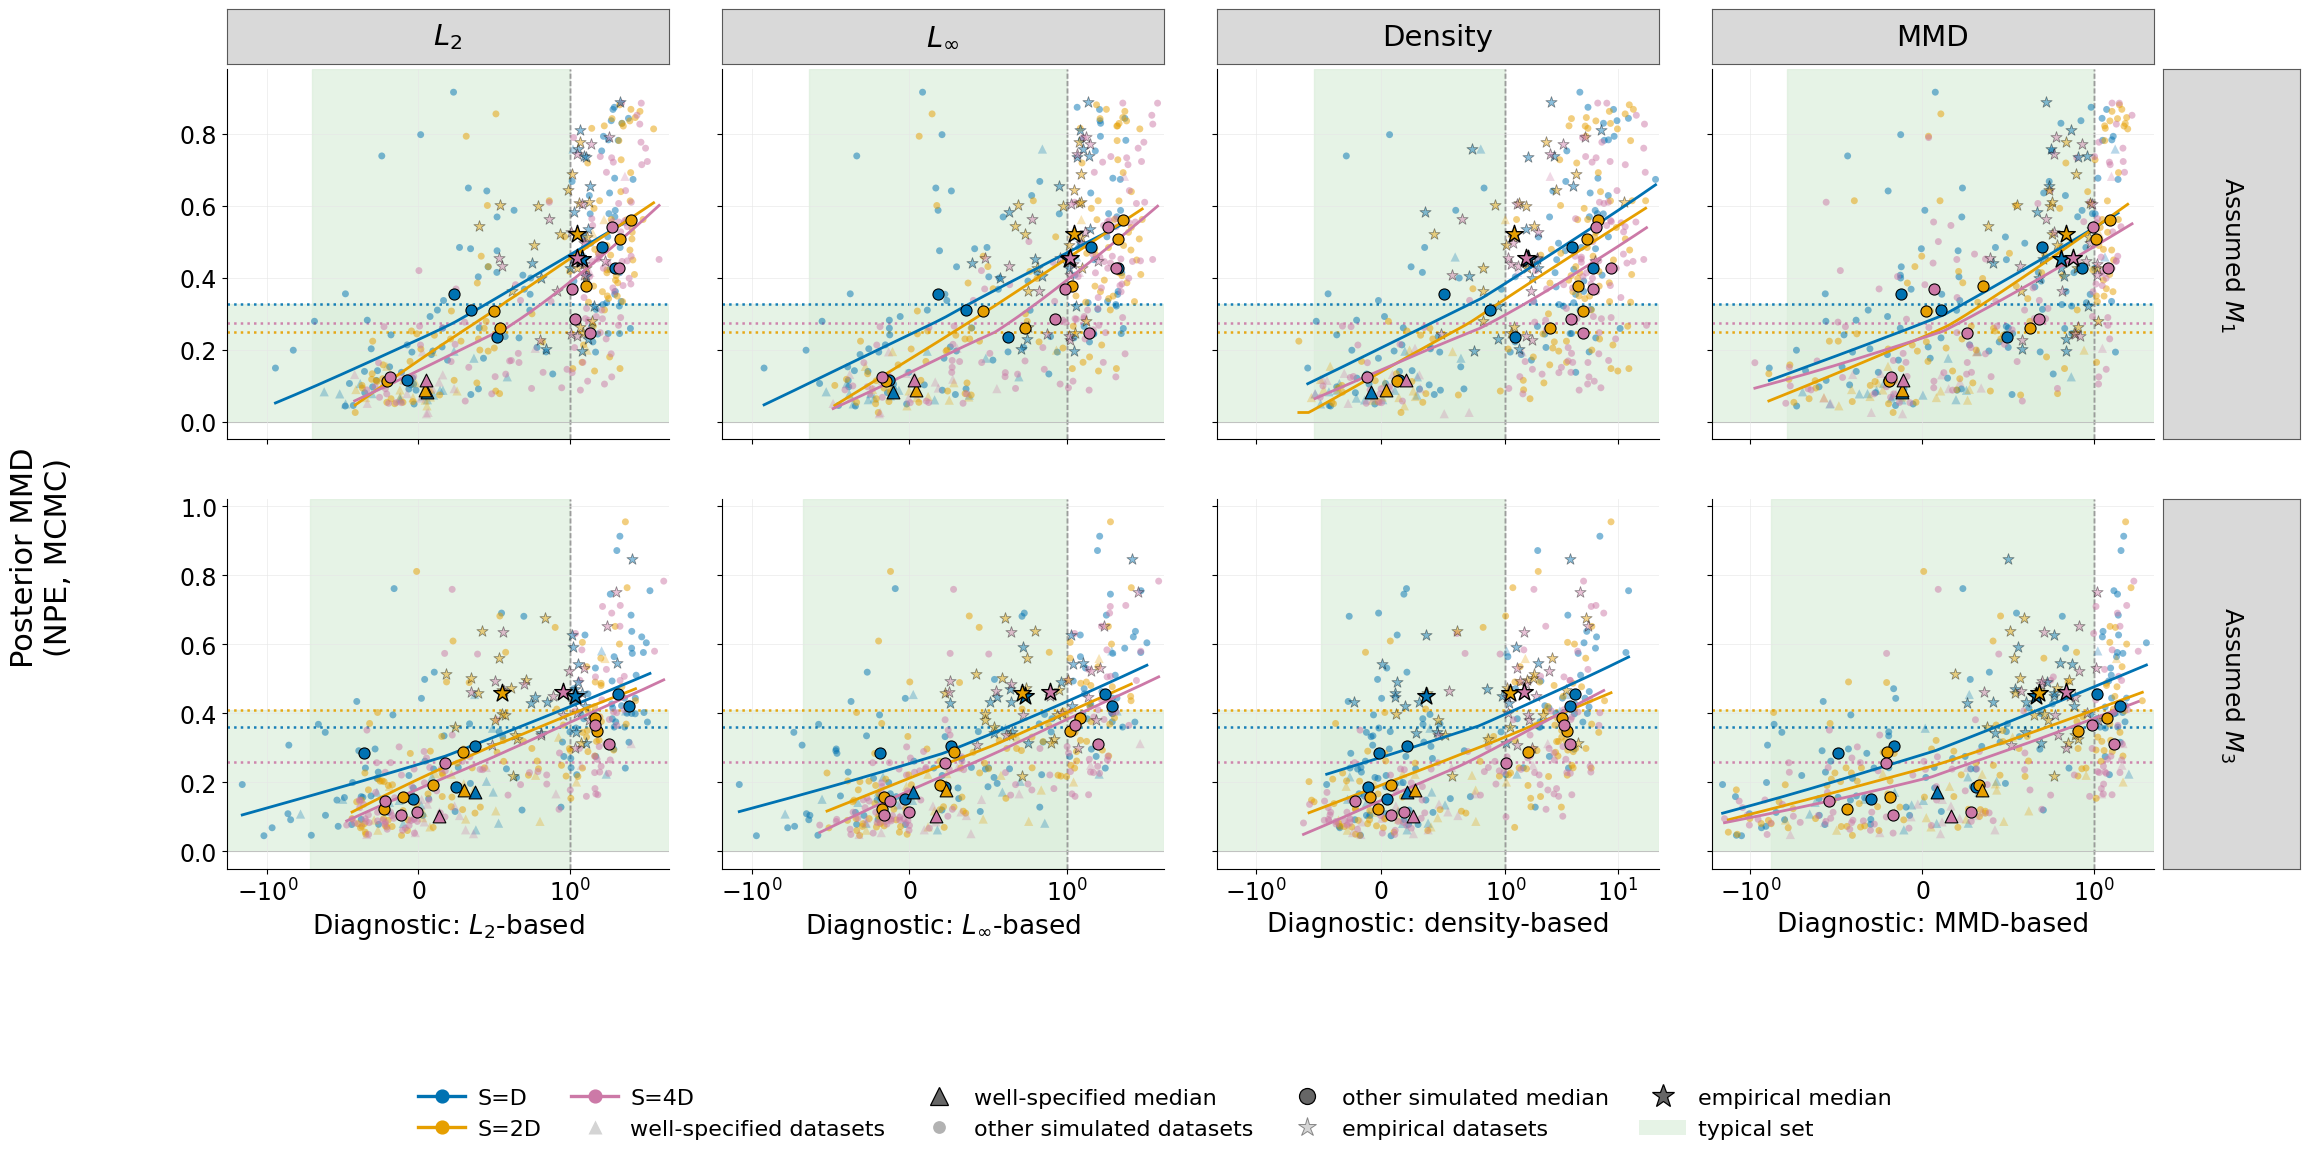

In [4]:
fig_run1_mmd, _, _ = plot_run_metric_grid("run1", "posterior_mmd")
plt.show()

Saved no-MMD-loss run 1: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run1/log10_logml_error_M1_M3_by_diagnostic.png


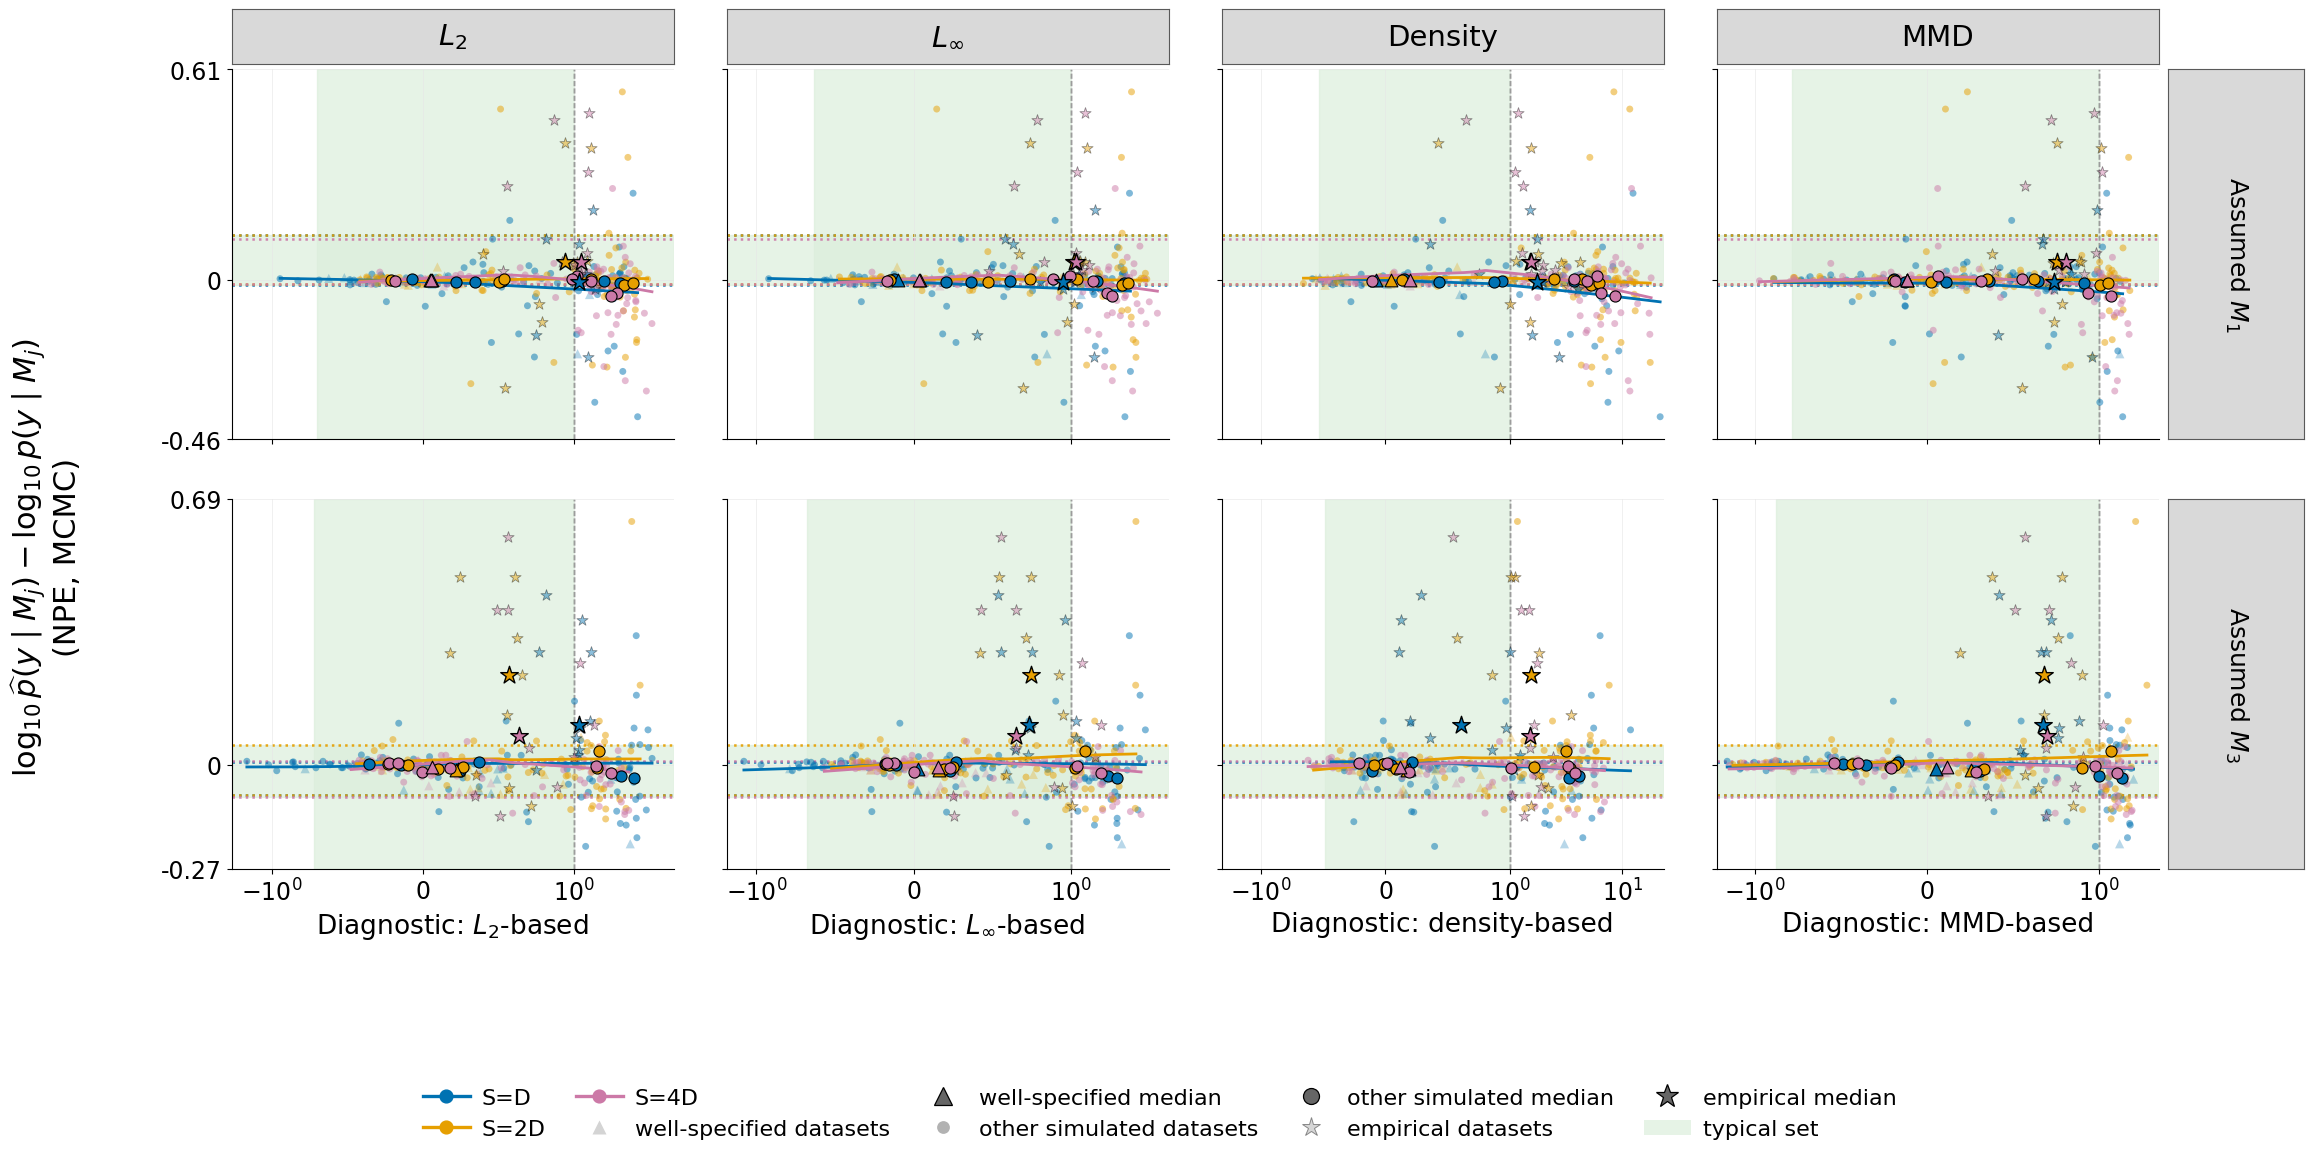

In [5]:
fig_run1_logml, _, _ = plot_run_metric_grid("run1", "log10_logml_error")
plt.show()

Saved no-MMD-loss run 1: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run1/pmp_error_M1_M3_by_diagnostic.png


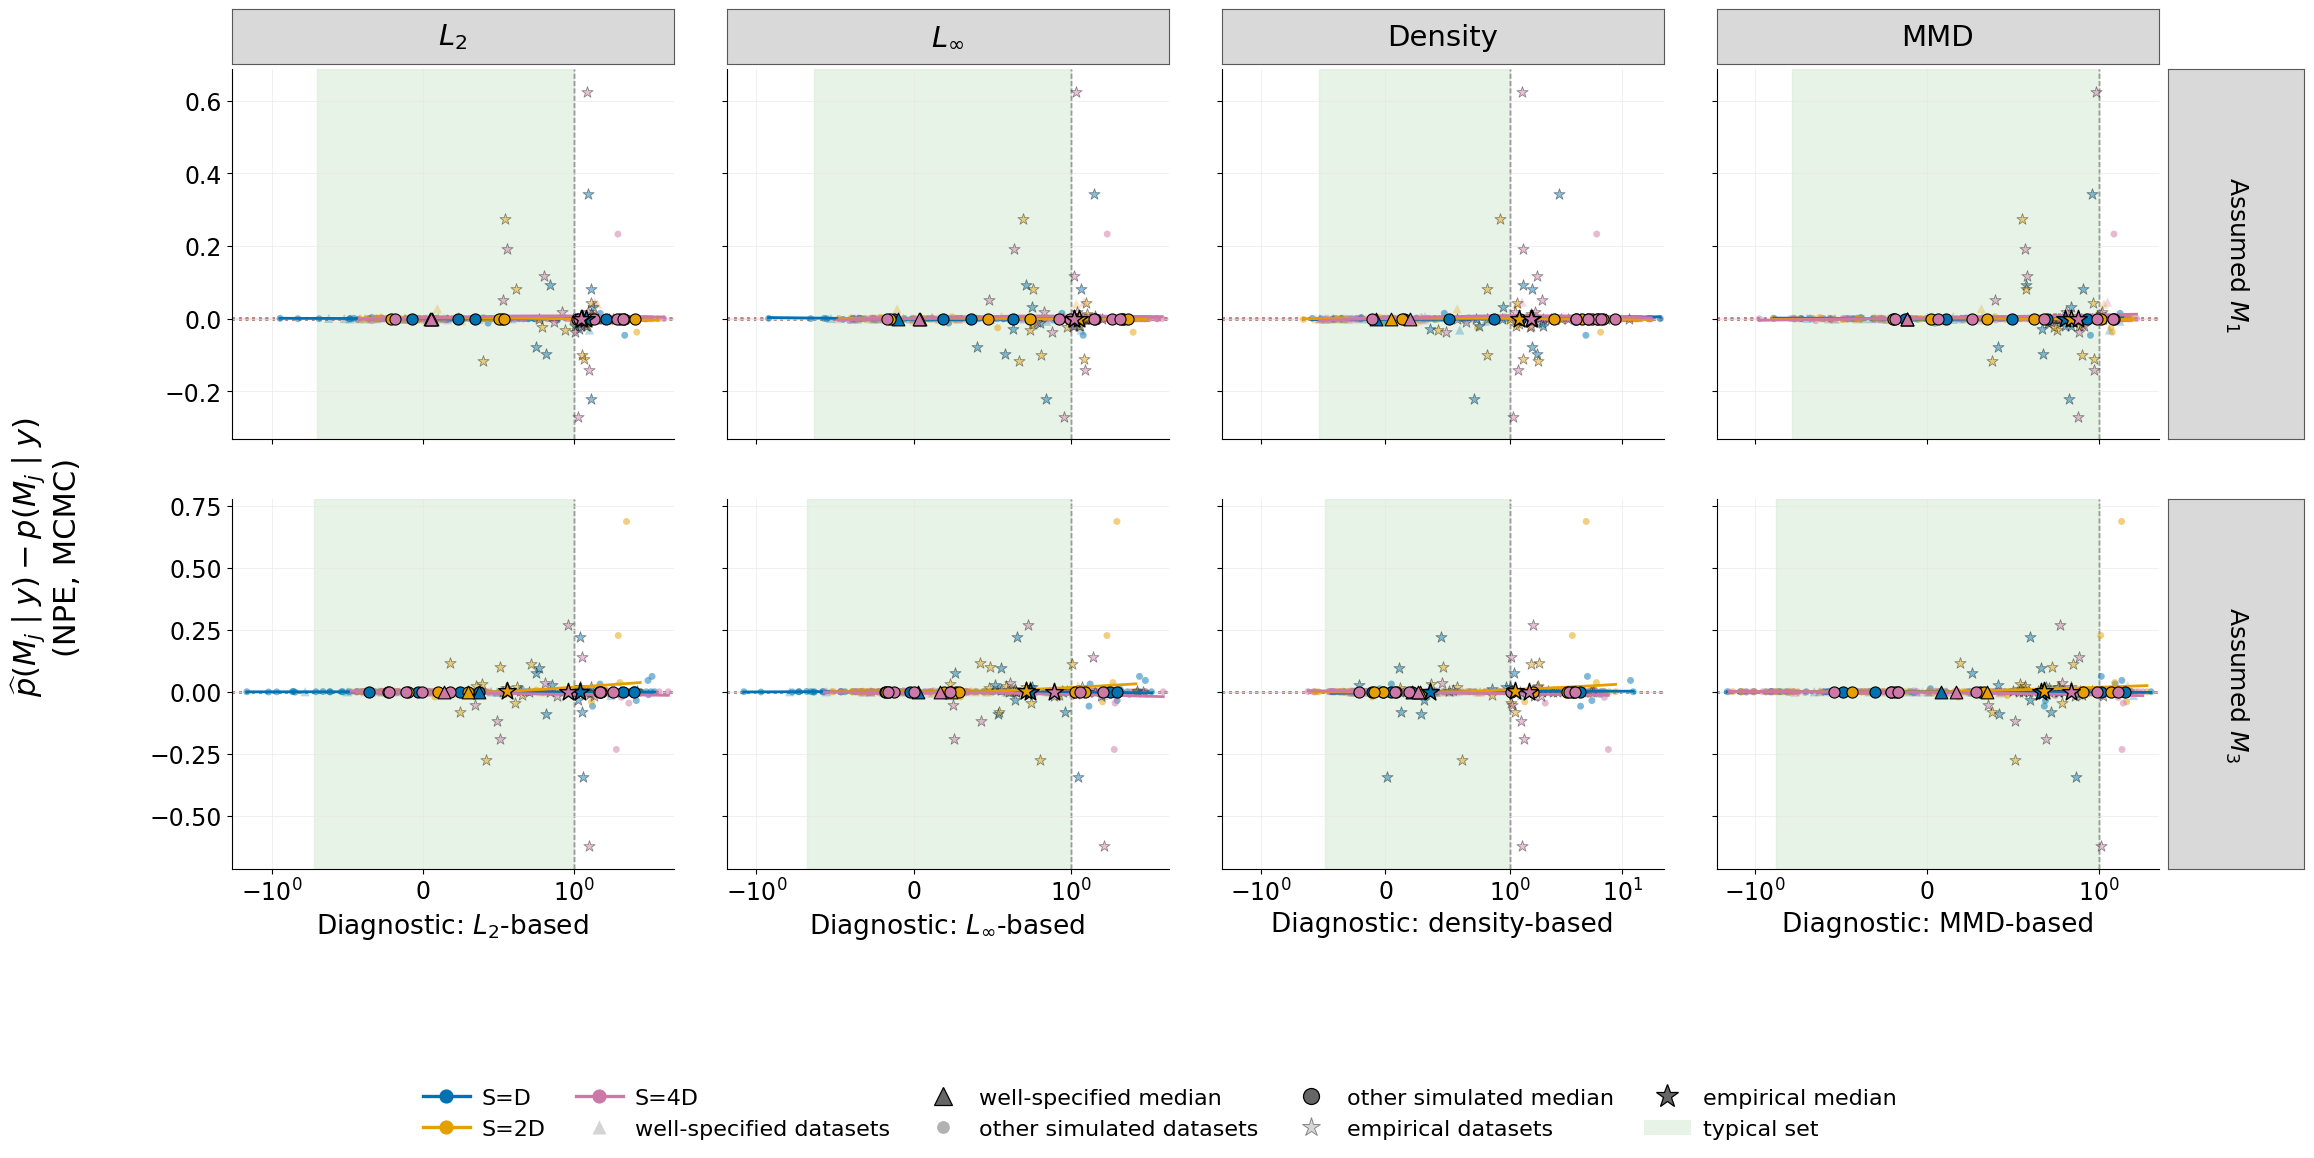

In [6]:
fig_run1_pmp, _, _ = plot_run_metric_grid("run1", "pmp_error")
plt.show()

## No-MMD-loss run 2

Saved no-MMD-loss run 2: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run2/posterior_mmd_M1_M3_by_diagnostic.png


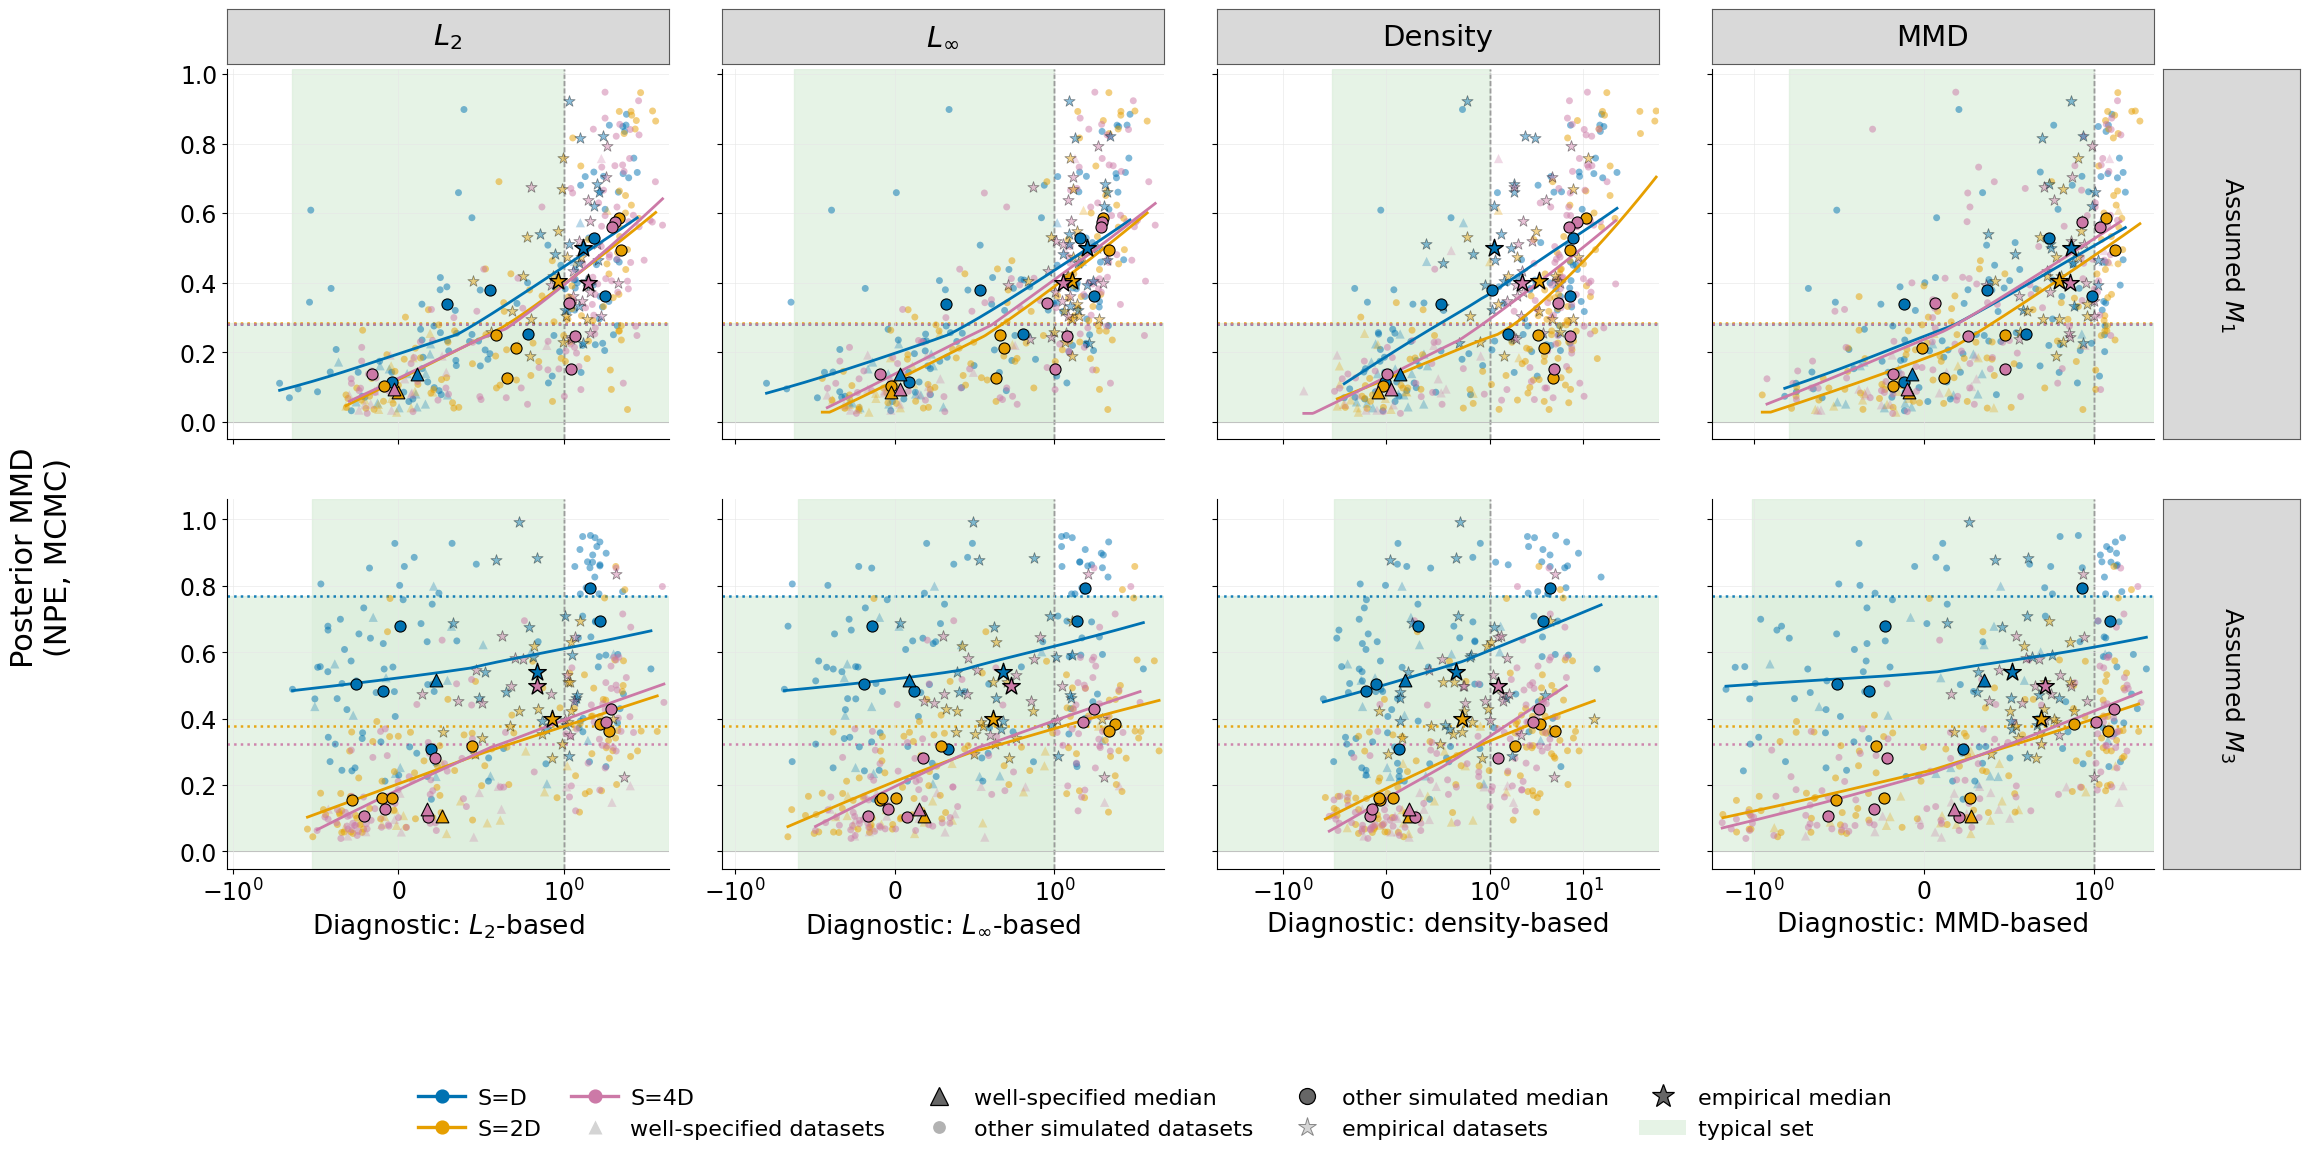

In [7]:
fig_run2_mmd, _, _ = plot_run_metric_grid("run2", "posterior_mmd")
plt.show()

Saved no-MMD-loss run 2: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run2/log10_logml_error_M1_M3_by_diagnostic.png


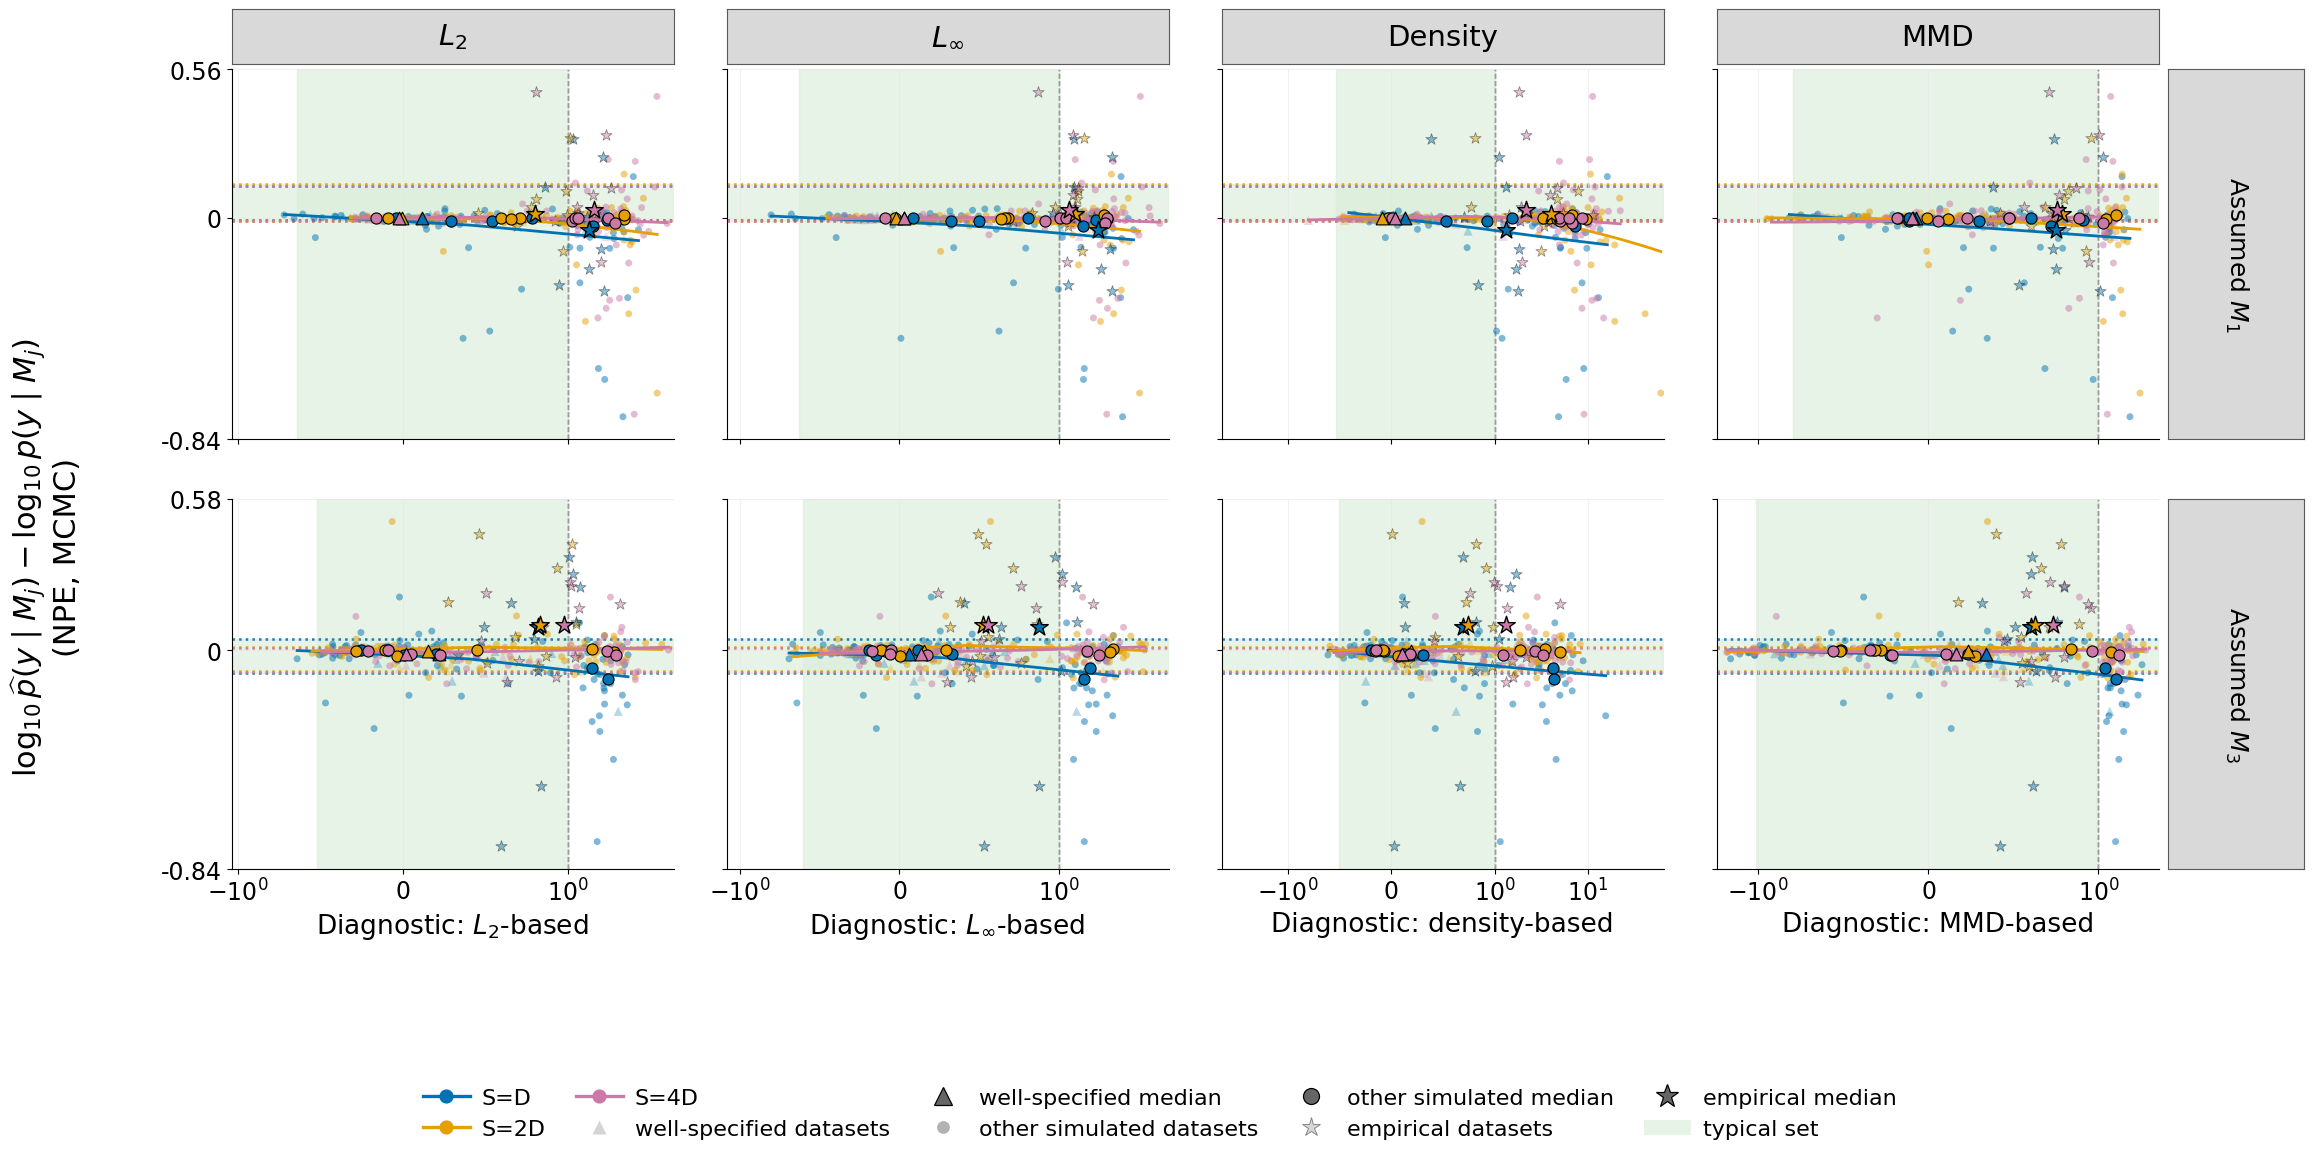

In [8]:
fig_run2_logml, _, _ = plot_run_metric_grid("run2", "log10_logml_error")
plt.show()

Saved no-MMD-loss run 2: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run2/pmp_error_M1_M3_by_diagnostic.png


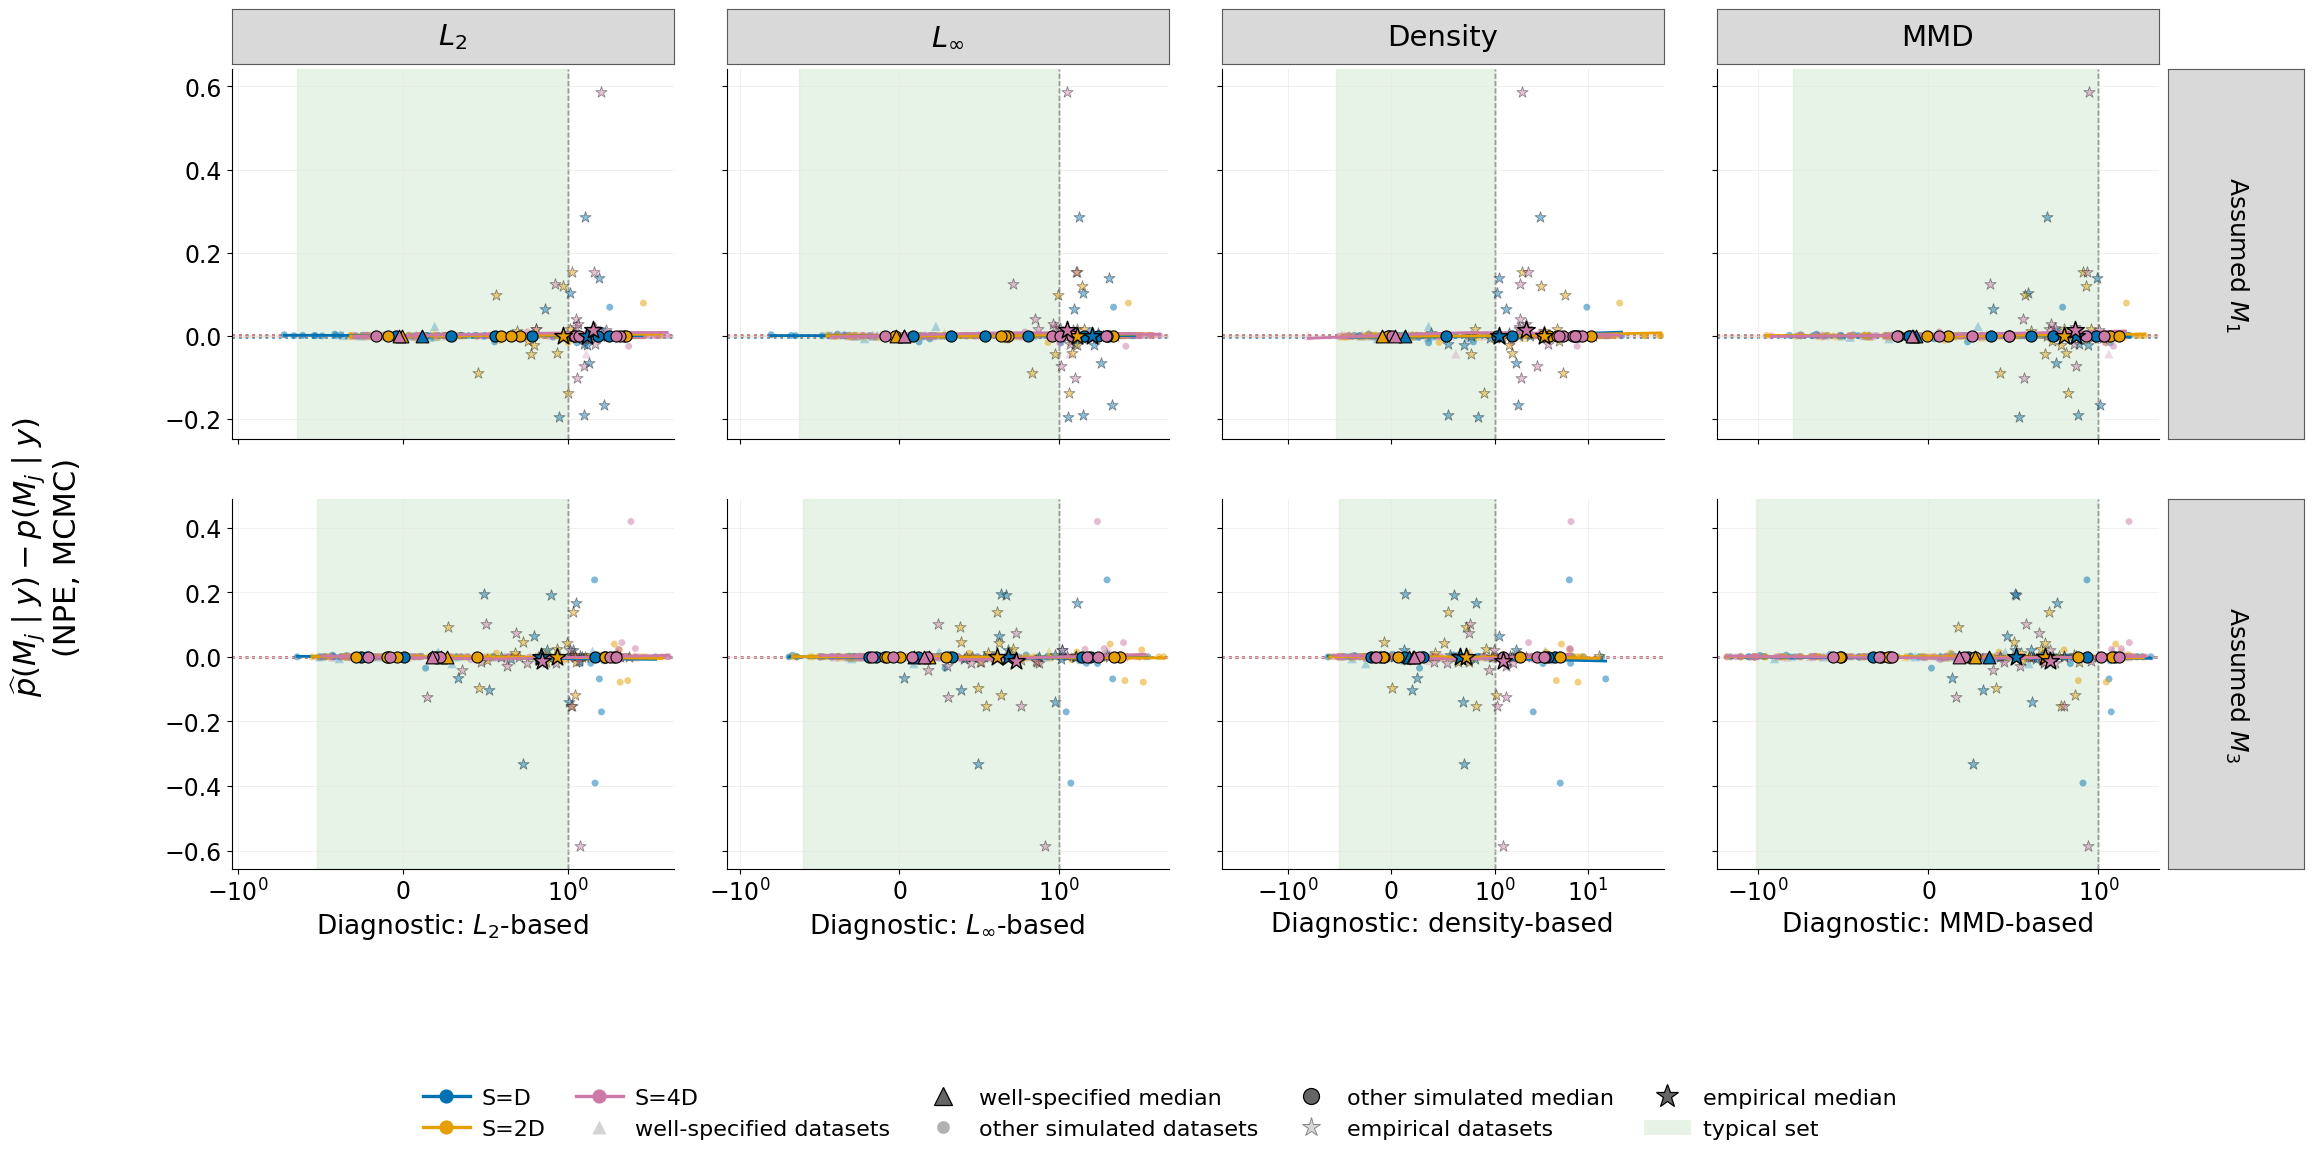

In [9]:
fig_run2_pmp, _, _ = plot_run_metric_grid("run2", "pmp_error")
plt.show()

## Gold-standard PMP overview (4 × 4)

Rows combine assumed model and summary dimension; columns show L2, Linf,
density, and MMD diagnostics. Run 1 and run 2 are generated separately below.

In [10]:
from matplotlib.colors import Normalize


PMP_OVERVIEW_ROWS = (
    ("m1", "S=D", r"Assumed $M_1$, $S=D$"),
    ("m3", "S=D", r"Assumed $M_3$, $S=D$"),
    ("m1", "S=4D", r"Assumed $M_1$, $S=4D$"),
    ("m3", "S=4D", r"Assumed $M_3$, $S=4D$"),
)
GOLD_PMP_CMAP = "turbo"
GOLD_PMP_LOWESS_FRAC = 0.7
GOLD_PMP_LOWESS_LINEWIDTH = 3.0
GOLD_PMP_POINT_STYLES = {
    False: {"marker": "o", "size": 56, "label": "all high surprise"},
    True: {
        "marker": "D",
        "size": 82,
        "label": "at least one not high surprise",
    },
}


def _gold_pmp_overview_handles():
    handles = [
        Line2D(
            [0], [0], marker=style["marker"], color="none",
            markerfacecolor="0.5", markeredgecolor="none",
            markersize=1.18 * np.sqrt(style["size"]),
            label=style["label"],
        )
        for style in GOLD_PMP_POINT_STYLES.values()
    ]
    handles.append(
        Line2D(
            [0], [0], marker="o", color="none",
            markerfacecolor="black", markeredgecolor="none",
            markersize=10, label="empirical",
        )
    )
    return handles


def _add_gold_pmp_max_error(ax, panel, value_column="pmp_error"):
    within_typical = panel.loc[panel["rho"].le(1.0)]
    if within_typical.empty:
        return
    extreme = within_typical.loc[
        within_typical[value_column].abs().idxmax()
    ]
    extreme_y = float(extreme[value_column])
    ax.axhline(
        extreme_y, color="#7A0276", linestyle="--",
        linewidth=1.1, zorder=4,
    )
    ax.text(
        0.02, extreme_y, f"{extreme_y:.2g}",
        transform=ax.get_yaxis_transform(),
        ha="left", va="top", color="#7A0276", fontsize=13,
        clip_on=False,
        bbox={
            "facecolor": "white", "edgecolor": "none",
            "alpha": 0.65, "pad": 1.0,
        },
    )


def _add_pmp_overview_strips(fig, axes):
    strip_color = "#D9D9D9"
    edge_color = "0.35"
    top_height = 0.058
    right_width = 0.052
    pad = 0.005

    for ax, diagnostic in zip(
        axes[0], PLOT_DIAGNOSTICS, strict=True
    ):
        position = ax.get_position()
        strip = fig.add_axes([
            position.x0, position.y1 + pad,
            position.width, top_height,
        ])
        strip.set_facecolor(strip_color)
        strip.text(
            0.5, 0.5, DIAGNOSTIC_TITLES[diagnostic],
            ha="center", va="center", fontsize=20,
        )
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)

    for ax, (_, _, label) in zip(
        axes[:, -1], PMP_OVERVIEW_ROWS, strict=True
    ):
        position = ax.get_position()
        strip = fig.add_axes([
            position.x1 + pad, position.y0,
            right_width, position.height,
        ])
        strip.set_facecolor(strip_color)
        strip.text(
            0.5, 0.5, label,
            ha="center", va="center", rotation=-90, fontsize=20,
        )
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(edge_color)


def plot_gold_pmp_overview_4x4(run_key):
    run_config = RUN_CONFIGS[run_key]
    data = comparison_by_run[run_key]
    plot_data = data.loc[
        data["dataset"].eq("empirical")
        & data["model"].isin(PLOT_MODELS)
        & data["summary"].isin(("S=D", "S=4D"))
        & data["diagnostic"].isin(PLOT_DIAGNOSTICS)
    ].copy()
    if plot_data.empty:
        raise ValueError(f"No empirical PMP rows for {run_config['label']}")

    threshold_columns = (
        "pmp_error_lower_threshold",
        "pmp_error_upper_threshold",
    )
    threshold_values = tuple(
        value
        for column in threshold_columns
        for value in pd.to_numeric(
            plot_data[column], errors="coerce"
        ).dropna().unique()
    )
    y_limits = _limits(
        plot_data["pmp_error"],
        include=(0.0, *threshold_values),
        padding=0.06,
    )
    x_limits = {
        diagnostic: _limits(
            pd.concat([
                plot_data.loc[
                    plot_data["diagnostic"].eq(diagnostic), "rho"
                ],
                plot_data.loc[
                    plot_data["diagnostic"].eq(diagnostic), "rho_low"
                ],
            ]),
            include=(1.0,),
            padding=0.08,
        )
        for diagnostic in PLOT_DIAGNOSTICS
    }

    norm = Normalize(vmin=0.0, vmax=1.0, clip=True)
    cmap = plt.get_cmap(GOLD_PMP_CMAP)
    fig, axes = plt.subplots(
        len(PMP_OVERVIEW_ROWS), len(PLOT_DIAGNOSTICS),
        figsize=(20.5, 19.5), sharex="col", sharey=True, squeeze=False,
    )
    fig.subplots_adjust(
        left=0.11, right=0.845, bottom=0.15, top=0.875,
        wspace=0.18, hspace=0.22,
    )

    for row, (model, summary, _) in enumerate(PMP_OVERVIEW_ROWS):
        for col, diagnostic in enumerate(PLOT_DIAGNOSTICS):
            ax = axes[row, col]
            panel = plot_data.loc[
                plot_data["diagnostic"].eq(diagnostic)
                & plot_data["model"].eq(model)
                & plot_data["summary"].eq(summary)
            ].dropna(subset=[
                "rho", "rho_low", "gold_pmp", "pmp_error",
                "at_least_one_not_high_surprise",
            ])

            ax.set_xscale(
                "symlog", base=10.0,
                linthresh=RHO_SYMLOG_LINTHRESH, linscale=1.0,
            )
            ax.set_xlim(*x_limits[diagnostic])
            ax.set_ylim(*y_limits)
            ax.axhline(0.0, color="0.35", linewidth=0.8, zorder=1)

            bounds = []
            for column in threshold_columns:
                unique = pd.to_numeric(
                    panel[column], errors="coerce"
                ).dropna().unique()
                if len(unique) != 1:
                    raise ValueError(
                        f"Expected one {column} for "
                        f"{diagnostic}/{model}/{summary}; found {len(unique)}"
                    )
                bounds.append(float(unique[0]))
            bounds = tuple(bounds)

            ax.axvspan(
                float(panel["rho_low"].median()), 1.0,
                color=TYPICAL_SET_FILL, alpha=0.55, zorder=0,
            )
            ax.axhspan(
                min(bounds), max(bounds),
                color=TYPICAL_SET_FILL, alpha=0.55, zorder=0,
            )
            for threshold in bounds:
                ax.axhline(
                    threshold, color="0.35", linestyle="--",
                    linewidth=THRESHOLD_LINEWIDTH, zorder=1,
                )
            ax.axvline(
                1.0, color="black", linestyle="--",
                linewidth=1.0, zorder=1,
            )
            _add_gold_pmp_max_error(ax, panel)

            for flag, style in GOLD_PMP_POINT_STYLES.items():
                points = panel.loc[
                    panel["at_least_one_not_high_surprise"].eq(flag)
                ]
                if points.empty:
                    continue
                ax.scatter(
                    points["rho"], points["pmp_error"],
                    c=points["gold_pmp"], cmap=cmap, norm=norm,
                    s=style["size"], marker=style["marker"],
                    alpha=0.65, edgecolors="black",
                    linewidths=0.5, zorder=3,
                )

            curve_x, curve_y = _lowess_curve(
                panel["rho"], panel["pmp_error"],
                frac=GOLD_PMP_LOWESS_FRAC,
            )
            ax.plot(
                curve_x, curve_y, color="black", linestyle="--",
                linewidth=GOLD_PMP_LOWESS_LINEWIDTH, zorder=4,
            )
            ax.grid(alpha=0.18)
            ax.tick_params(
                labelsize=15,
                labelleft=col == 0,
                labelbottom=row == len(PMP_OVERVIEW_ROWS) - 1,
            )
            ax.set_xlabel("")
            ax.set_ylabel("")

    fig.supylabel(
        r"$\widehat{p}(M_j\mid y)-p(M_j\mid y)$" + "\n(NPE, MCMC)",
        x=0.026, fontsize=22,
        ha="center", va="center", multialignment="center",
    )
    fig.supxlabel(
        r"Diagnostic score $\rho$", y=0.098, fontsize=20
    )
    _add_pmp_overview_strips(fig, axes)
    fig.legend(
        handles=_gold_pmp_overview_handles(),
        loc="lower center", bbox_to_anchor=(0.475, 0.028),
        ncol=3, frameon=False, fontsize=17, markerscale=1.1,
        columnspacing=1.6, handletextpad=0.65,
    )
    colorbar_ax = fig.add_axes([0.945, 0.22, 0.018, 0.56])
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=colorbar_ax
    )
    colorbar.set_label("Gold-standard PMP", fontsize=19, labelpad=12)
    colorbar.ax.tick_params(labelsize=15)

    output_dir = OUTPUT_ROOT / run_key
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "pmp_error_gold_standard_overview_4x4.png"
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    print(f"Saved {run_config['label']} PMP overview: {output_path}")
    return fig, axes, output_path

Saved no-MMD-loss run 1 PMP overview: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run1/pmp_error_gold_standard_overview_4x4.png


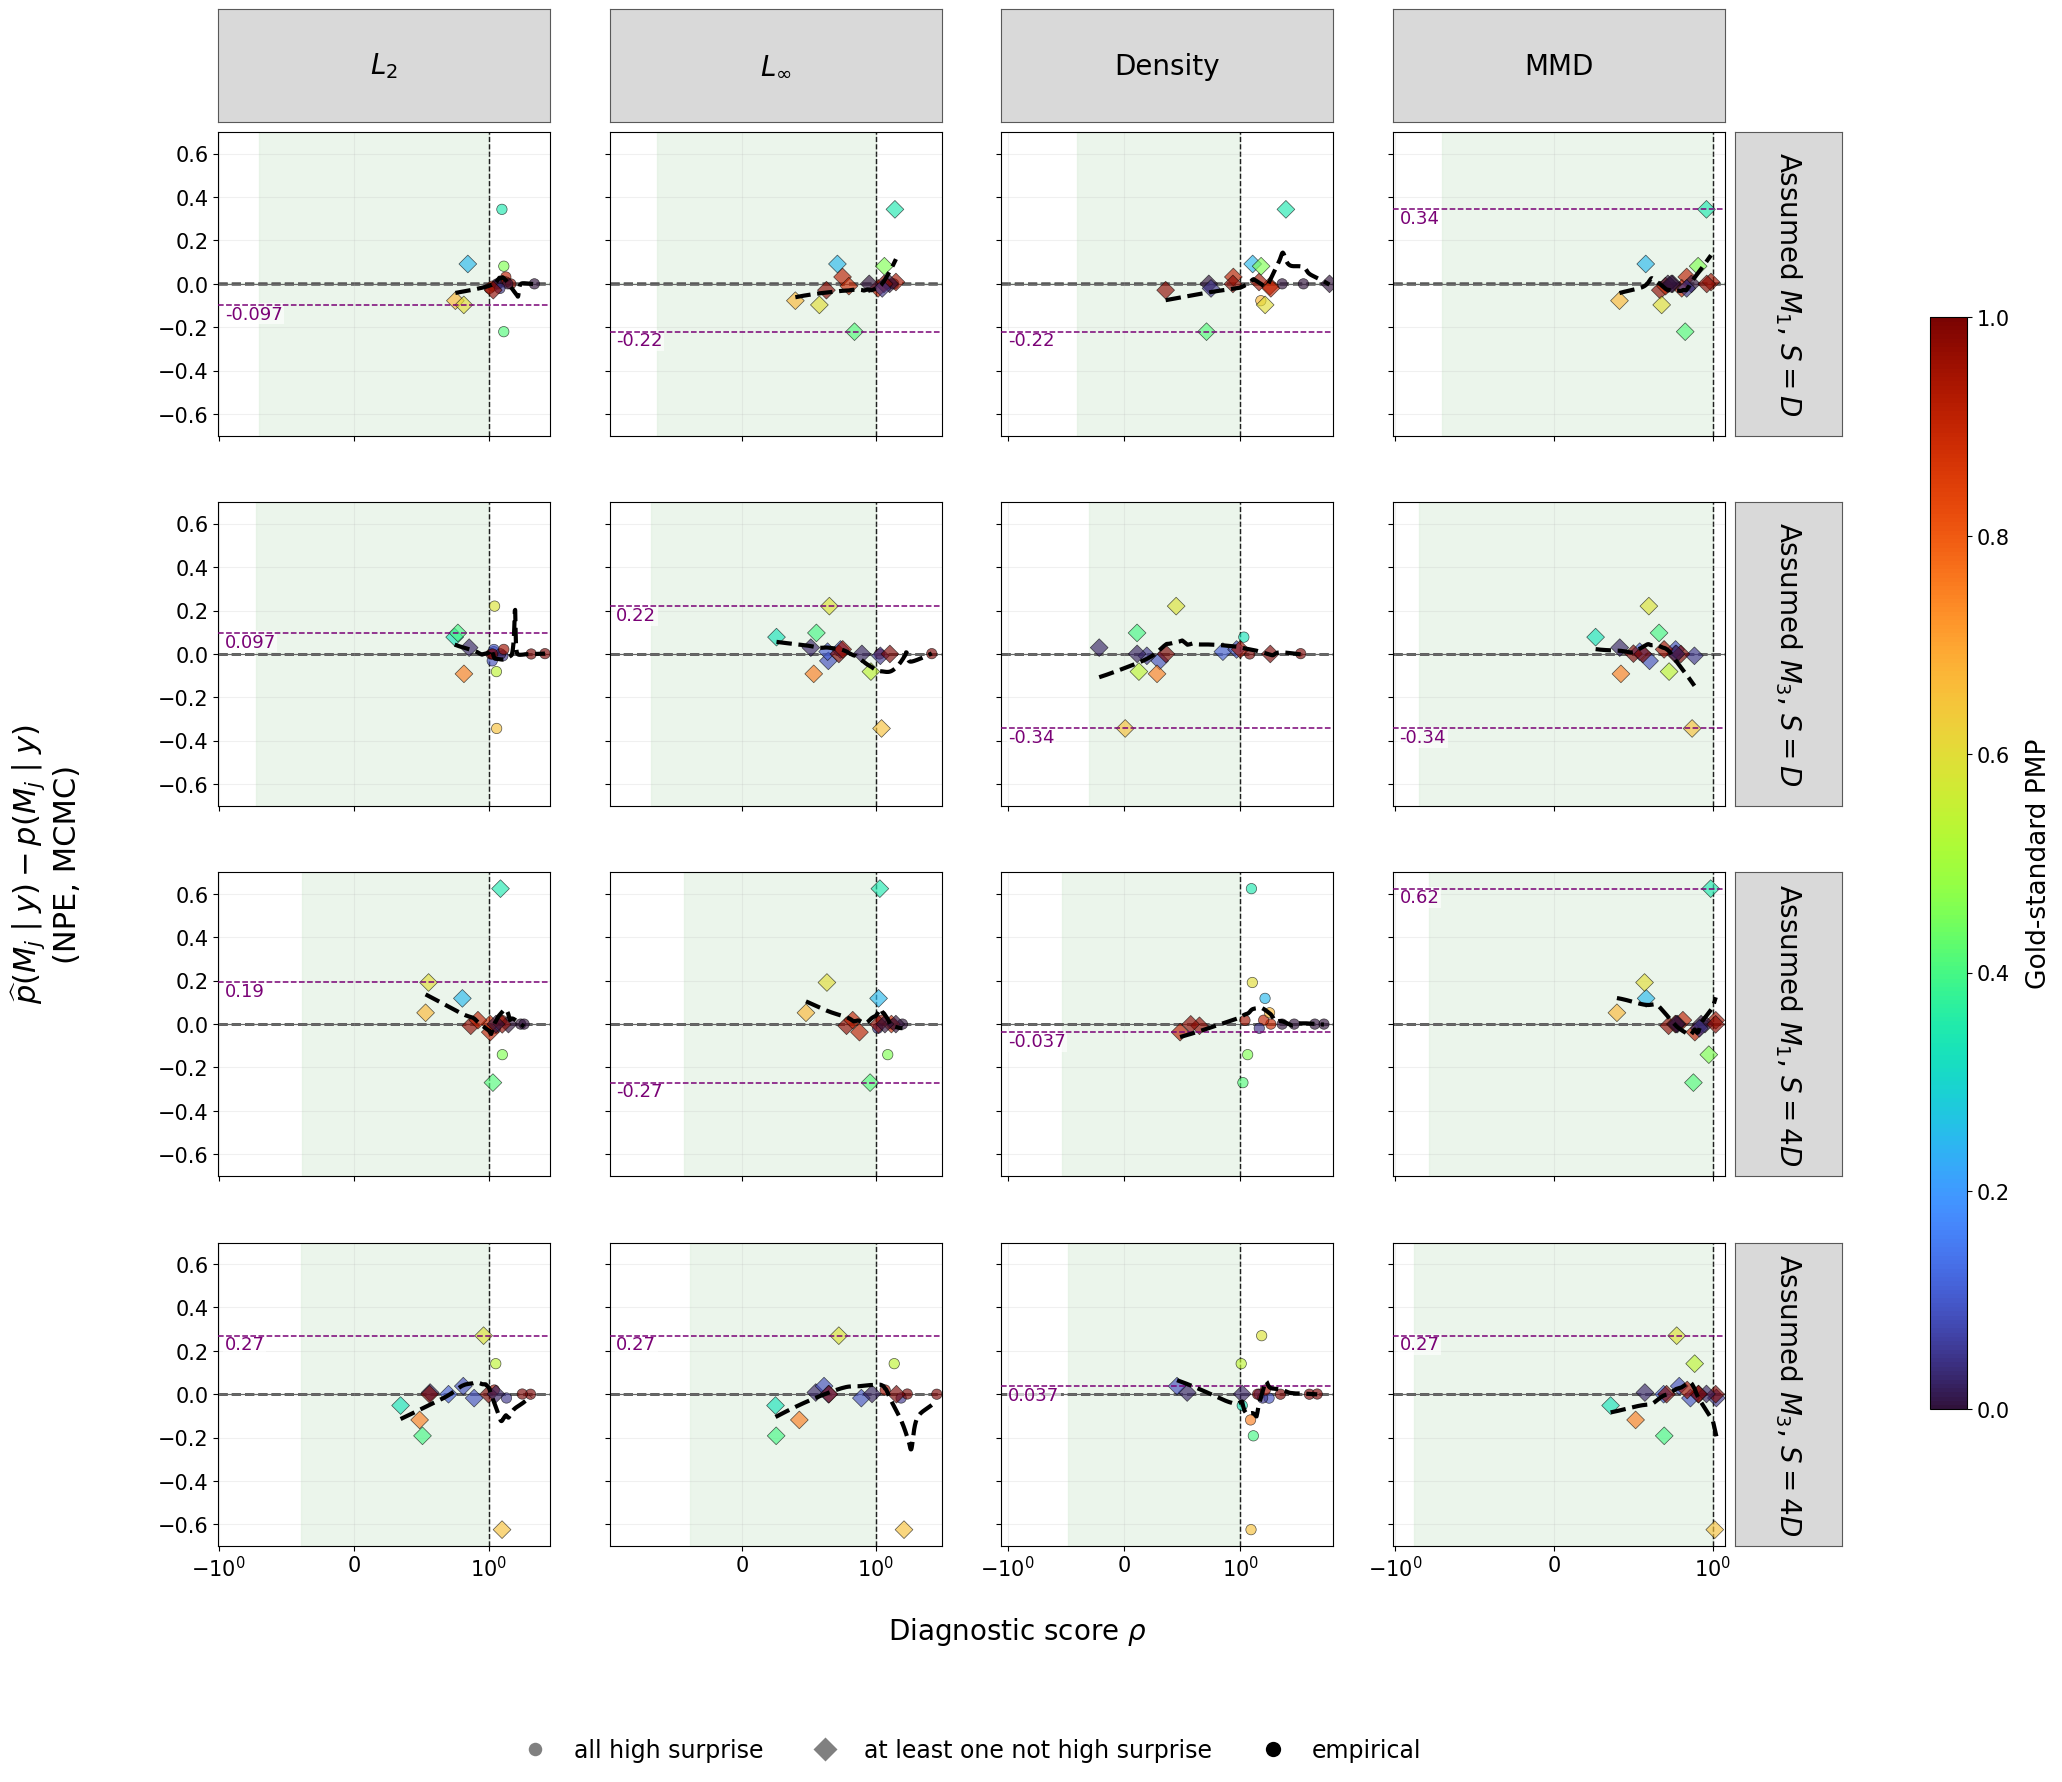

In [11]:
fig_run1_pmp_overview, _, _ = plot_gold_pmp_overview_4x4("run1")
plt.show()

Saved no-MMD-loss run 2 PMP overview: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_noMMDloss_runs_M1_M3_2x4/run2/pmp_error_gold_standard_overview_4x4.png


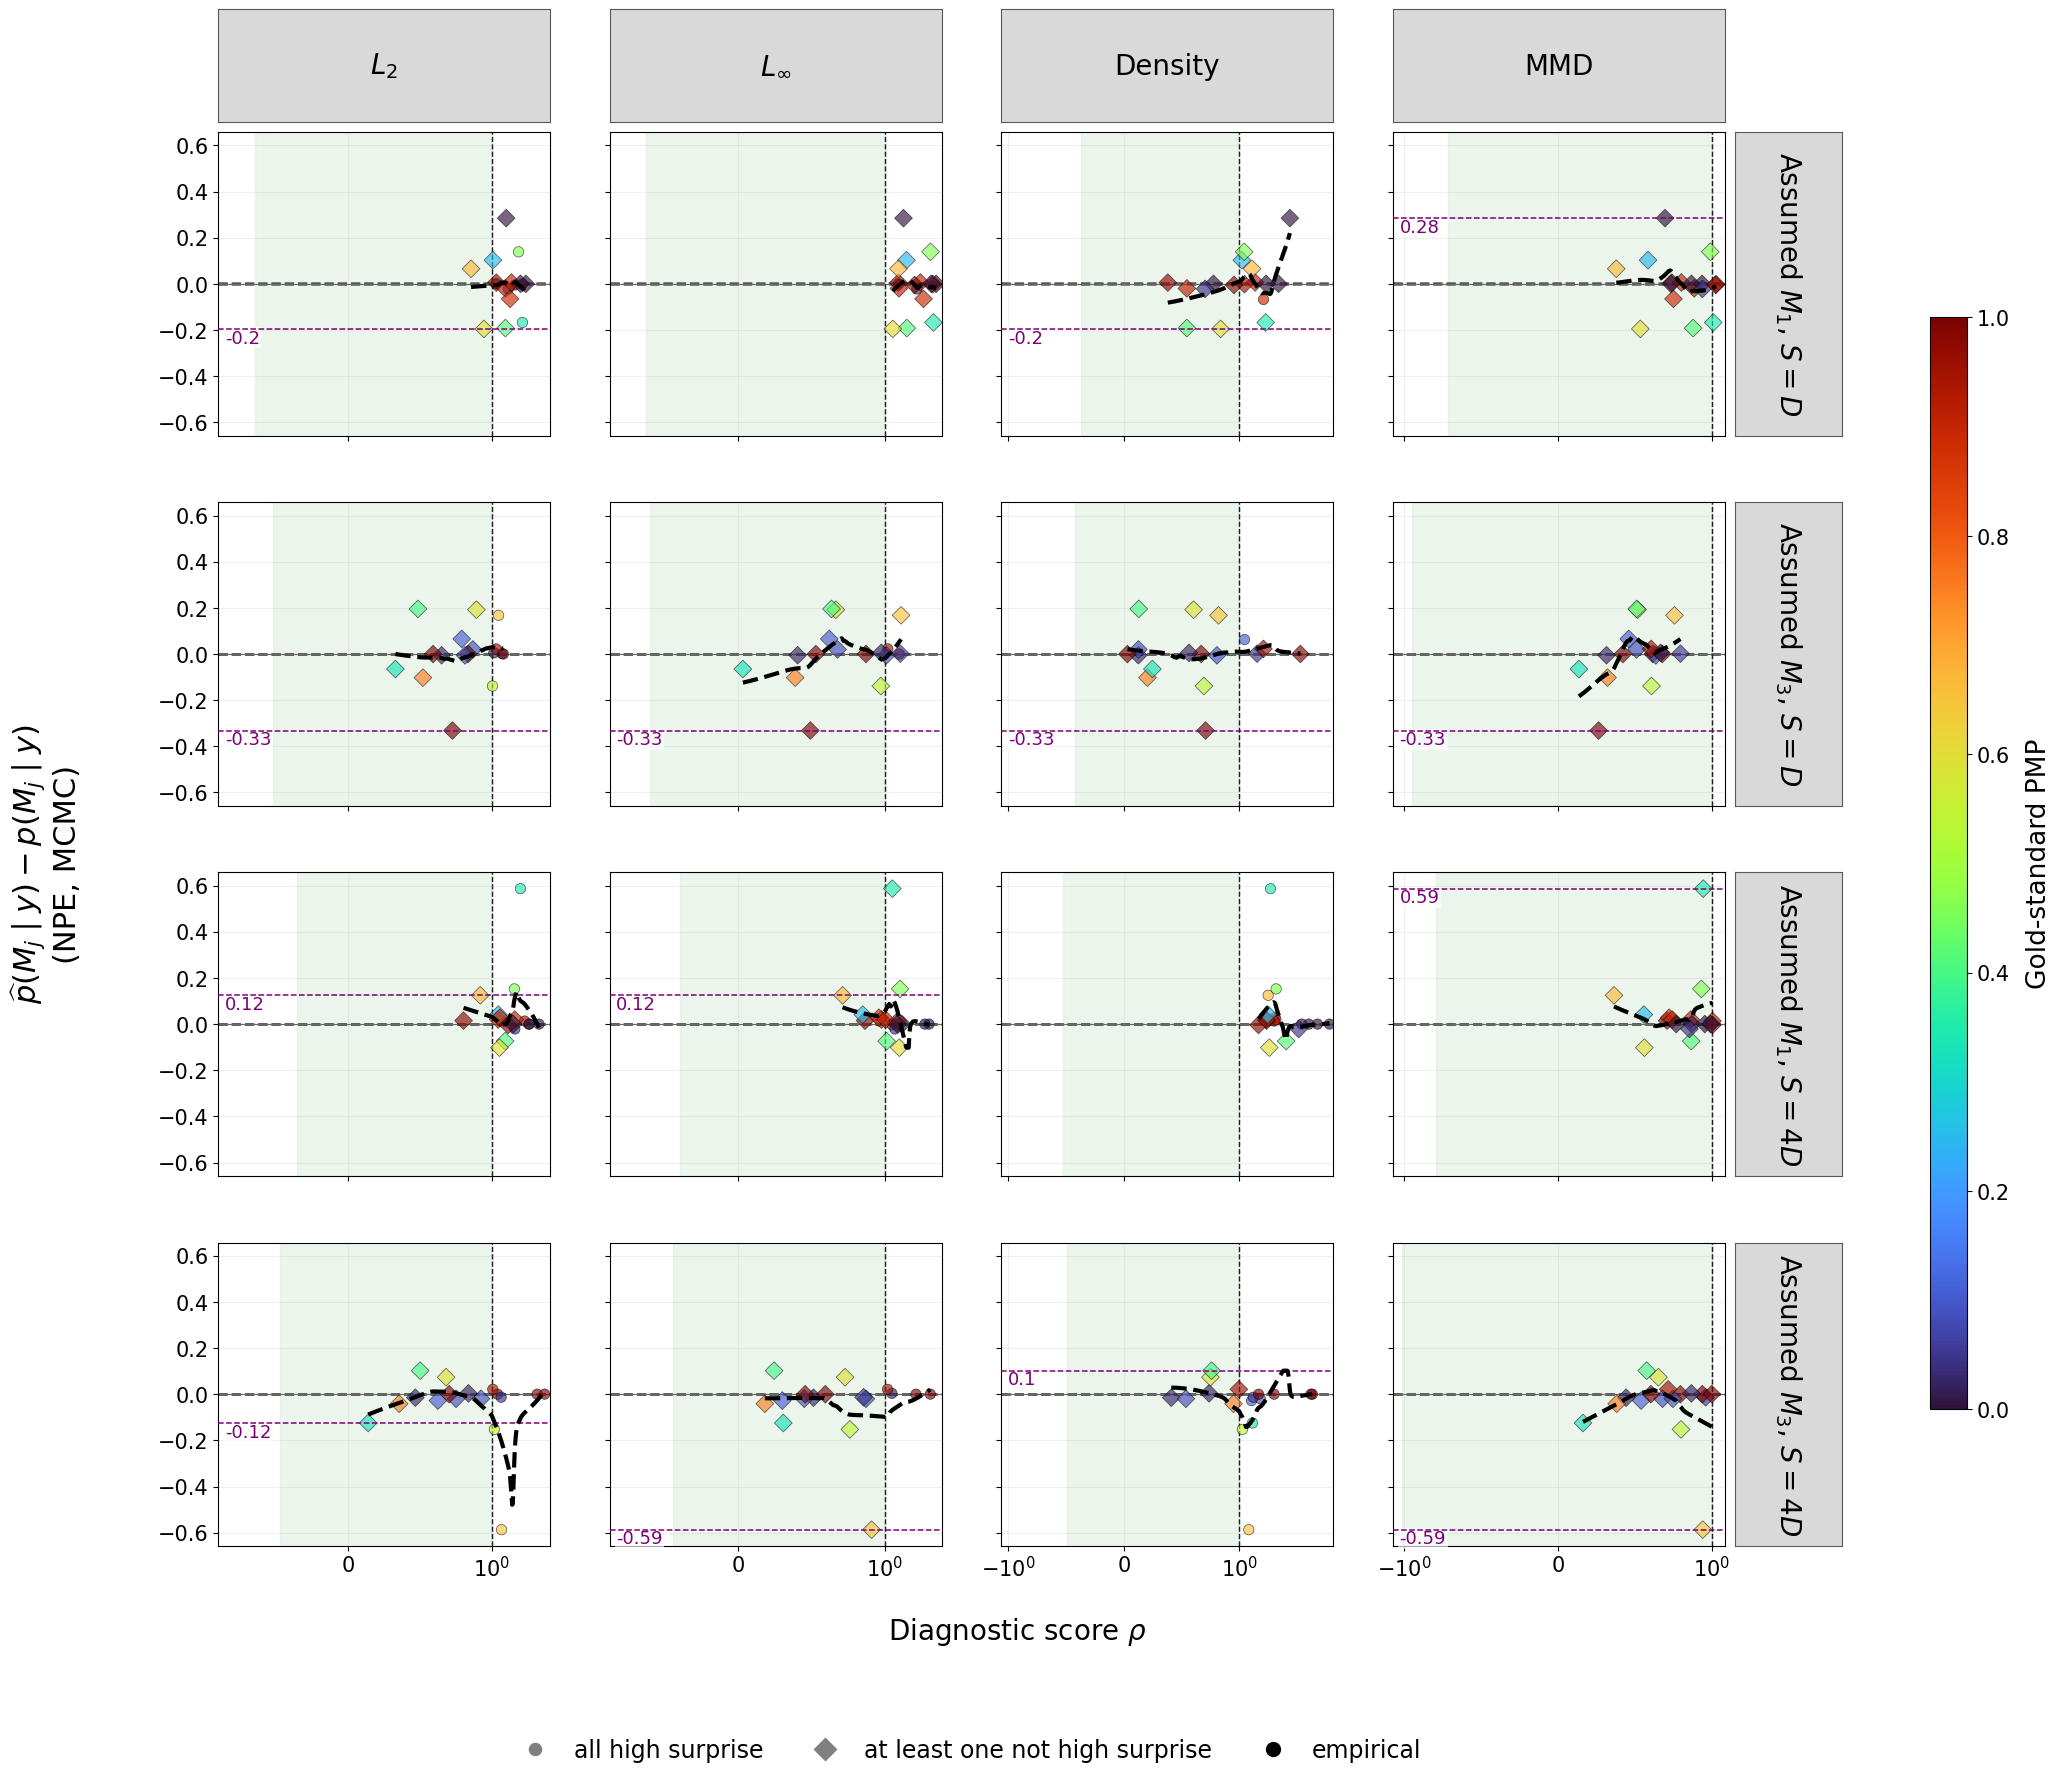

In [12]:
fig_run2_pmp_overview, _, _ = plot_gold_pmp_overview_4x4("run2")
plt.show()